# HR Attrition — Production Preprocessing for XGBoost
**Pipeline:** Protected Attribute Isolation → Ordinal/OHE Encoding → HuggingFace Sentiment → Stratified Split → Class Weight Calculation

Target: `Attrition_Target` (1 = left, 0 = stayed). Highly imbalanced; handled via `scale_pos_weight`.

## 0. Imports & Config

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import pipeline
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Global Config ────────────────────────────────────────────────────────────
RANDOM_STATE    = 42
TEST_SIZE       = 0.20
TARGET_COL      = 'Attrition_Target'
PROTECTED_COLS  = ['Age', 'Gender', 'Marital_Status']

# ── Data Paths ───────────────────────────────────────────────────────────────
DATA_DIR = '.'
PATH_EMPLOYEE     = f'{DATA_DIR}/employee_data.csv'
PATH_COMPENSATION = f'{DATA_DIR}/compensation_data.csv'
PATH_SURVEY       = f'{DATA_DIR}/survey_results.csv'
PATH_ATTRITION    = f'{DATA_DIR}/attrition_data.csv'
PATH_MARKET       = f'{DATA_DIR}/market_benchmarks.csv'

# ── Encoding Config ───────────────────────────────────────────────────────────
# NOTE: Values match actual Education_Level entries in employee_data.csv.
# Associate added; keys corrected from 'Bachelors'/'Masters' → 'Bachelor'/'Master'

ORDINAL_MAPS = {
    'Education_Level': {
        'High School': 1,
        'Associate':   2,
        'Bachelor':    3,
        'Master':      4,
        'PhD':         5
    },
}

NOMINAL_COLS     = ['Department', 'Employment_Type', 'Work_Location']
TEXT_COL         = 'Feedback_Comments'
SENTIMENT_COL    = 'Feedback_Sentiment'
SENTIMENT_MODEL  = 'distilbert-base-uncased-finetuned-sst-2-english'
SENTIMENT_BATCH  = 32

print("Config loaded")
print(f"   Random state    : {RANDOM_STATE}")
print(f"   Test size       : {TEST_SIZE:.0%}")
print(f"   Target column   : {TARGET_COL}")
print(f"   Protected cols  : {PROTECTED_COLS}")
print(f"   Ordinal cols    : {list(ORDINAL_MAPS.keys())}")
print(f"   Nominal cols    : {NOMINAL_COLS}")
print(f"   Text column     : {TEXT_COL}  →  will become  {SENTIMENT_COL}")
print(f"   Sentiment model : {SENTIMENT_MODEL}")

Config loaded
   Random state    : 42
   Test size       : 20%
   Target column   : Attrition_Target
   Protected cols  : ['Age', 'Gender', 'Marital_Status']
   Ordinal cols    : ['Education_Level']
   Nominal cols    : ['Department', 'Employment_Type', 'Work_Location']
   Text column     : Feedback_Comments  →  will become  Feedback_Sentiment
   Sentiment model : distilbert-base-uncased-finetuned-sst-2-english


## 1. Load Data

In [49]:
# ── Load all 5 source files ──────────────────────────────────────────────────
employee     = pd.read_csv(PATH_EMPLOYEE)
compensation = pd.read_csv(PATH_COMPENSATION)
survey       = pd.read_csv(PATH_SURVEY)
attrition    = pd.read_csv(PATH_ATTRITION)
market       = pd.read_csv(PATH_MARKET)

# ── Encode target BEFORE merge ────────────────────────────────────────────────
# Attrition_Date has 8192 NaNs by design (stayers have no exit date) — drop it.
attrition[TARGET_COL] = (attrition['Attrition_Status'] == 'Yes').astype(int)
attrition = attrition[['Employee_ID', TARGET_COL]]

# ── Derive Compa_Ratio from market benchmarks ─────────────────────────────────
comp_with_benchmark = compensation.merge(
    employee[['Employee_ID', 'Role', 'Work_Location']],
    on='Employee_ID'
).merge(
    market.rename(columns={'Location': 'Work_Location'}),
    on=['Role', 'Work_Location'],
    how='left'
)
comp_with_benchmark['Compa_Ratio'] = (
    comp_with_benchmark['Base_Salary'] / comp_with_benchmark['Benchmark_Salary']
)

# ── Master merge (all joins on Employee_ID) ───────────────────────────────────
df = (
    employee
    .merge(survey[['Employee_ID', 'Job_Satisfaction', 'Work_Life_Balance',
                   'Management_Support', 'Career_Development',
                   'Engagement_Level', 'Feedback_Comments']],
           on='Employee_ID')
    .merge(comp_with_benchmark[['Employee_ID', 'Base_Salary', 'Bonus',
                                 'Stock_Options', 'Total_Compensation',
                                 'Compa_Ratio']],
           on='Employee_ID')
    .merge(attrition, on='Employee_ID')
)

df = df.drop(columns=['Employee_ID', 'Role'])

In [50]:
# ── Post-merge Summary ────────────────────────────────────────────────────────

print(f"Master dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Dropped columns explanation 
print("\n── Columns Dropped & Why ─────────────────────────────────────────────")
dropped = {
    'Employee_ID' : 'Row identifier — carries no predictive signal; would cause data leakage.',
    'Role'        : 'High-cardinality free-text label — already used to compute Compa_Ratio; redundant post-merge.',
}
for col, reason in dropped.items():
    print(f"  ✗  {col:<20}  →  {reason}")

# ── Final 20 columns explained
print("\n── Final Columns in df ───────────────────────────────────────────────")
col_descriptions = {
    # ── From employee_data.csv ──
    'Age'                : '[employee]  Protected attribute — age of the employee.',
    'Gender'             : '[employee]  Protected attribute — gender of the employee.',
    'Marital_Status'     : '[employee]  Protected attribute — marital status.',
    'Department'         : '[employee]  Business unit / team the employee belongs to.',
    'Education_Level'    : '[employee]  Highest qualification (ordinal: HS → PhD).',
    'Employment_Type'    : '[employee]  Full-time / Part-time / Contract.',
    'Work_Location'      : '[employee]  Office / Remote / Hybrid.',
    'Tenure_Years'       : '[employee]  Tenure in years — proxy for loyalty & flight risk.',
    'Years_In_Role'      : '[employee]  Time in current role — stagnation signal.',
    # ── From survey_results.csv ──
    'Job_Satisfaction'   : '[survey]    Self-reported job satisfaction score.',
    'Work_Life_Balance'  : '[survey]    Self-reported work-life balance score.',
    'Management_Support' : '[survey]    Perceived managerial support score.',
    'Career_Development' : '[survey]    Perceived career growth opportunity score.',
    'Engagement_Level'   : '[survey]    Overall engagement score.',
    'Feedback_Comments'  : '[survey]    Raw free-text — will be converted to sentiment score.',
    # ── From compensation_data.csv + market_benchmarks.csv ──
    'Base_Salary'        : '[comp]      Annual base salary in USD.',
    'Bonus'              : '[comp]      Annual bonus in USD.',
    'Stock_Options'      : '[comp]      Vested stock options value.',
    'Total_Compensation' : '[comp]      Base + Bonus + Stock — overall pay package.',
    'Compa_Ratio'        : '[comp+mkt]  Base_Salary / Benchmark_Salary — pay competitiveness.',
    # ── Derived from attrition_data.csv ──
    'Attrition_Target'   : '[target]    Binary label: 1 = left, 0 = stayed.',
}

for i, col in enumerate(df.columns, 1):
    desc = col_descriptions.get(col, '[unknown]  No description available.')
    print(f"  {i:>2}. {col:<22}  {desc}")

Master dataset: 10,000 rows × 20 columns

── Columns Dropped & Why ─────────────────────────────────────────────
  ✗  Employee_ID           →  Row identifier — carries no predictive signal; would cause data leakage.
  ✗  Role                  →  High-cardinality free-text label — already used to compute Compa_Ratio; redundant post-merge.

── Final Columns in df ───────────────────────────────────────────────
   1. Age                     [employee]  Protected attribute — age of the employee.
   2. Gender                  [employee]  Protected attribute — gender of the employee.
   3. Department              [employee]  Business unit / team the employee belongs to.
   4. Tenure_Years            [employee]  Tenure in years — proxy for loyalty & flight risk.
   5. Employment_Type         [employee]  Full-time / Part-time / Contract.
   6. Education_Level         [employee]  Highest qualification (ordinal: HS → PhD).
   7. Marital_Status          [employee]  Protected attribute — marital s

In [51]:
# ── Target distribution ───────────────────────────────────────────────────────
print(f"\n── Target Distribution ───────────────────────────────────────────────")
print(df[TARGET_COL].value_counts().to_string())
print(f"\n   Attrition rate: {df[TARGET_COL].mean():.2%}")

# ── Null check ────────────────────────────────────────────────────────────────
print(f"\n── Null Check ────────────────────────────────────────────────────────")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print(nulls.to_string() if not nulls.empty else "  ✓  No nulls detected across all columns.")


── Target Distribution ───────────────────────────────────────────────
Attrition_Target
0    8192
1    1808

   Attrition rate: 18.08%

── Null Check ────────────────────────────────────────────────────────
  ✓  No nulls detected across all columns.


## 2. Isolate Protected Attributes

**Why this matters mathematically:**  
XGBoost is a greedy ensemble of CART trees. At each node, it evaluates every feature using the gain formula:

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

where $G$ = sum of first-order loss gradients and $H$ = sum of second-order (Hessian) terms. If `Gender` or `Age` statistically correlates with attrition (even spuriously from historical HR decisions), this gain will be nonzero and the feature **will** be selected. The model encodes the bias into tree weights. Isolating them prevents this entirely while preserving the data for post-hoc fairness audits (e.g., equal FPR/FNR across demographic groups).

In [52]:
# ── Validate protected columns exist ─────────────────────────────────────────
missing_protected = [c for c in PROTECTED_COLS if c not in df.columns]
if missing_protected:
    raise ValueError(f"Protected columns not found: {missing_protected}")

cols_before = list(df.columns)
protected_df = df[PROTECTED_COLS].copy()
model_df     = df.drop(columns=PROTECTED_COLS).copy()

removed = [c for c in cols_before if c not in model_df.columns]
print(f"   Protected attribute isolation")
print(f"   Columns BEFORE : {len(cols_before)}  →  {cols_before}")
print(f"   Removed        : {removed}  (stored in protected_df for fairness audits)")
print(f"   Columns AFTER  : {len(model_df.columns)}  →  {list(model_df.columns)}")


   Protected attribute isolation
   Columns BEFORE : 20  →  ['Age', 'Gender', 'Department', 'Tenure_Years', 'Employment_Type', 'Education_Level', 'Marital_Status', 'Work_Location', 'Job_Satisfaction', 'Work_Life_Balance', 'Management_Support', 'Career_Development', 'Engagement_Level', 'Feedback_Comments', 'Base_Salary', 'Bonus', 'Stock_Options', 'Total_Compensation', 'Compa_Ratio', 'Attrition_Target']
   Removed        : ['Age', 'Gender', 'Marital_Status']  (stored in protected_df for fairness audits)
   Columns AFTER  : 17  →  ['Department', 'Tenure_Years', 'Employment_Type', 'Education_Level', 'Work_Location', 'Job_Satisfaction', 'Work_Life_Balance', 'Management_Support', 'Career_Development', 'Engagement_Level', 'Feedback_Comments', 'Base_Salary', 'Bonus', 'Stock_Options', 'Total_Compensation', 'Compa_Ratio', 'Attrition_Target']


## 3. NLP Sentiment Extraction via HuggingFace

**Why this matters mathematically:**  
XGBoost splits on scalar thresholds like $x_j < \theta$. A raw string is a non-metric object with no defined ordering — it is impossible to compute a gradient or Hessian over it. A transformer encoder like DistilBERT maps the string into a dense continuous vector via its attention mechanism, then projects the pooled `[CLS]` embedding through a classification head to produce a probability $p \in [0, 1]$. We sign-flip negatives to yield a bipolar scalar $s \in [-1, 1]$, creating a proper real-valued feature the gradient boosting math can act on.

In [53]:
# ── Load sentiment pipeline ───────────────────────────────────────────────────
print(f"Loading sentiment model: {SENTIMENT_MODEL}")
print("Maps free-text → signed scalar in [-1, 1]")
print("  POSITIVE confidence → +score  |  NEGATIVE confidence → −score\n")

sentiment_pipe = pipeline(
    task       = "sentiment-analysis",
    model      = SENTIMENT_MODEL,
    truncation = True,
    max_length = 512,
    device     = -1,
    batch_size = SENTIMENT_BATCH
)

def score_to_signed(result: dict) -> float:
    s = result['score']
    return s if result['label'] == 'POSITIVE' else -s

# ── Pre-inference audit ───────────────────────────────────────────────────────
texts_raw  = model_df[TEXT_COL].fillna('').str.strip()
n_empty    = (texts_raw == '').sum()
n_total    = len(texts_raw)
texts_safe = [t if t else 'no comment provided' for t in texts_raw.tolist()]

print(f"Text column audit  [{TEXT_COL}]")
print(f"  Total records   : {n_total:,}")
print(f"  Empty / NaN     : {n_empty}  {'— replaced with neutral placeholder' if n_empty else '— none'}")
print(f"  Unique comments : {texts_raw.nunique()}")
print(f"  Sample texts    :")
for t in texts_raw.unique()[:3]:
    print(f"    · {t}")

# ── Batch inference ───────────────────────────────────────────────────────────
print(f"\nRunning inference on {n_total:,} records  (batch_size={SENTIMENT_BATCH}) ...")
raw_results = []
for i in tqdm(range(0, len(texts_safe), SENTIMENT_BATCH), desc="Sentiment batches"):
    raw_results.extend(sentiment_pipe(texts_safe[i : i + SENTIMENT_BATCH]))

model_df[SENTIMENT_COL] = [score_to_signed(r) for r in raw_results]

# ── Post-inference audit ──────────────────────────────────────────────────────
scores      = model_df[SENTIMENT_COL]
n_pos_sent  = (scores > 0).sum()
n_neg_sent  = (scores < 0).sum()
n_neut_sent = (scores == 0).sum()

print(f"\nSentiment scores → '{SENTIMENT_COL}'")
print(f"  Range    : [{scores.min():.4f},  {scores.max():.4f}]")
print(f"  Mean     : {scores.mean():.4f}   Median : {scores.median():.4f}")
print(f"  Positive : {n_pos_sent:,}  ({n_pos_sent/n_total:.1%})")
print(f"  Negative : {n_neg_sent:,}  ({n_neg_sent/n_total:.1%})")
print(f"  Neutral  : {n_neut_sent}  (empty-text placeholders only)")

# ── Drop raw text column ──────────────────────────────────────────────────────
model_df = model_df.drop(columns=[TEXT_COL])
print(f"\n'{TEXT_COL}' dropped — signal captured by '{SENTIMENT_COL}'")
print(f"model_df shape after replacement: {model_df.shape}")

Loading sentiment model: distilbert-base-uncased-finetuned-sst-2-english
Maps free-text → signed scalar in [-1, 1]
  POSITIVE confidence → +score  |  NEGATIVE confidence → −score



Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1172.64it/s]


Text column audit  [Feedback_Comments]
  Total records   : 10,000
  Empty / NaN     : 0  — none
  Unique comments : 25
  Sample texts    :
    · Salary is decent but bonuses could be better.
    · Work is okay but growth opportunities are limited.
    · Very happy with my role, learning a lot every day.

Running inference on 10,000 records  (batch_size=32) ...


Sentiment batches: 100%|██████████| 313/313 [00:36<00:00,  8.63it/s]


Sentiment scores → 'Feedback_Sentiment'
  Range    : [-0.9998,  0.9999]
  Mean     : 0.6660   Median : 0.9993
  Positive : 8,385  (83.9%)
  Negative : 1,615  (16.2%)
  Neutral  : 0  (empty-text placeholders only)

'Feedback_Comments' dropped — signal captured by 'Feedback_Sentiment'
model_df shape after replacement: (10000, 17)


## 4. Categorical Encoding

**Why this matters mathematically:**

**Ordinal encoding** is appropriate when the variable has a *known, meaningful rank order*. For `Education_Level`, assigning integers `{1,2,3,4}` allows the tree to learn thresholds like `Education_Level >= 3` (i.e., Masters or above). The integer gap is irrelevant to CART — only the rank matters for split selection.

**One-Hot Encoding** is appropriate for *nominal* variables with no intrinsic order. If we label-encode `Department` as `{Sales=1, IT=2, HR=3}`, the model falsely assumes `IT(2) > Sales(1)`, which is meaningless and injects false gradient information. OHE converts each category into a binary indicator column, and XGBoost can split on any of them independently.

**Note on `drop_first`:** In logistic regression, dropping one dummy variable prevents perfect multicollinearity. XGBoost (a tree ensemble) is *not* affected by multicollinearity — it's not solving a linear system. Dropping a category removes information and can create split ambiguity. We keep all dummies.

 ═══════════════════════════════════════════════════════════════════════════════
 STEP 4 — CATEGORICAL ENCODING
 ═══════════════════════════════════════════════════════════════════════════════

 WHAT THIS STEP DOES
 ─────────────────────
   4.1  Ordinal encoding  → Education_Level mapped to int rank  (±0 cols)
   4.2  One-hot encoding  → 3 nominal cols replaced with dummy columns
          Department      :  5 categories  → 5 binary cols  (−1 + 5 = net +4)
          Employment_Type :  3 categories  → 3 binary cols  (−1 + 3 = net +2)
          Work_Location   :  3 categories  → 3 binary cols  (−1 + 3 = net +2)

Net column change from OHE: −3 originals + 11 dummies = +8

In [54]:
cols_before_encoding = list(model_df.columns)
print("=" * 70)
print("STEP 4 — CATEGORICAL ENCODING")
print("=" * 70)
print(f"\n  Columns ENTERING this step : {len(cols_before_encoding)}")
print(f"  {cols_before_encoding}\n")

# ── 4.1  Ordinal Encoding ────────────────────────────────────────────────────
# WHY ORDINAL HERE:
#   Education_Level has a clear, universally agreed-upon rank:
#       High School (1) < Associate (2) < Bachelor (3) < Master (4) < PhD (5)
#   Encoding as integers preserves this rank so that a tree-based model
#   can learn "employees with Education_Level >= 3 have lower attrition".
#   Using OHE would create 5 sparse binary columns AND destroy the rank signal,
#   forcing the model to re-learn from scratch what is already known.
#
# COLUMN IMPACT:  Education_Level is overwritten in-place → net 0 columns added.

print("─" * 70)
print("  4.1  Ordinal Encoding  (in-place replacement, ±0 column count)")
print("─" * 70)

for col, mapping in ORDINAL_MAPS.items():
    if col not in model_df.columns:
        print(f"  WARNING: '{col}' not found in model_df — skipping.")
        continue

    original_values = sorted(model_df[col].dropna().unique().tolist())

    # Safety check: every value in the data must exist in the mapping.
    # An unseen category would silently become NaN, which corrupts downstream steps.
    unseen = set(original_values) - set(mapping.keys())
    if unseen:
        raise ValueError(
            f"'{col}' contains values not in ORDINAL_MAPS: {unseen}\n"
            f"Please add them to ORDINAL_MAPS before continuing."
        )

    model_df[col] = model_df[col].map(mapping)

    encoded_values = sorted(model_df[col].dropna().unique().tolist())
    print(f"\n  Column  : '{col}'")
    print(f"  Before  : {original_values}")
    print(f"  Mapping : {mapping}")
    print(f"  After   : {encoded_values}")
    print(f"  Reason  : Clear ordinal hierarchy — integer rank lets the model split")
    print(f"            on Education_Level >= 3 (Bachelor+) without learning that")
    print(f"            'Bachelor' > 'Associate' from scratch.")
    print(f"  Net Δ   : 0  (value replaced in-place; column count unchanged)")

# ── 4.2  One-Hot Encoding ────────────────────────────────────────────────────
# WHY OHE HERE:
#   Department, Employment_Type, and Work_Location have NO natural rank.
#   Label-encoding them (e.g. Finance=0, HR=1, IT=2 ...) would falsely imply
#   that IT > HR > Finance, which the model would exploit as a spurious signal.
#   OHE creates one binary column per category, making each category independent.
#
# WHY drop_first=False (all dummies kept):
#   drop_first=True is a trick for linear models to avoid perfect multicollinearity
#   in the design matrix.  XGBoost is a tree-based model — it is immune to this
#   issue because each split considers one feature at a time.
#   Dropping a category removes information with no benefit; we keep all dummies.
#
# WHY dtype=np.int8:
#   Binary columns only ever hold 0 or 1.  int8 uses 1 byte vs int64's 8 bytes,
#   cutting memory use for these columns by 8×.  No precision is lost.
#
# COLUMN IMPACT (counted from actual category counts, verified below):
#   Department      → 5 dummies, −1 original = net +4
#   Employment_Type → 3 dummies, −1 original = net +2
#   Work_Location   → 3 dummies, −1 original = net +2
#   Total OHE net : +8 columns

print(f"\n{'─' * 70}")
print("  4.2  One-Hot Encoding  (nominal columns — no natural rank)")
print("─" * 70)

existing_nominal = [c for c in NOMINAL_COLS if c in model_df.columns]
missing_nominal  = [c for c in NOMINAL_COLS if c not in model_df.columns]

if missing_nominal:
    print(f"\n  WARNING: These nominal columns not found, skipping: {missing_nominal}")

for col in existing_nominal:
    cats = sorted(model_df[col].dropna().unique().tolist())
    net  = len(cats) - 1           # −1 original col, +len(cats) dummies
    print(f"\n  Column  : '{col}'")
    print(f"  Categories ({len(cats)}) : {cats}")
    print(f"  Produces : {len(cats)} binary dummy columns")
    print(f"  Net Δ   : −1 original + {len(cats)} dummies = +{net} columns")
    print(f"  Reason  : No natural order — label encoding would imply a false rank.")
    print(f"            drop_first=False: XGBoost is tree-based, not linear;")
    print(f"            multicollinearity is irrelevant. All categories kept.")

model_df = pd.get_dummies(
    model_df,
    columns   = existing_nominal,
    drop_first = False,
    dtype      = np.int8
)

# ── Encoding Summary ─────────────────────────────────────────────────────────
cols_after_encoding  = list(model_df.columns)
new_dummy_cols       = [c for c in cols_after_encoding if c not in cols_before_encoding]
removed_nominal_cols = [c for c in cols_before_encoding if c not in cols_after_encoding]

print(f"\n{'=' * 70}")
print("  ENCODING SUMMARY")
print(f"{'=' * 70}")
print(f"  Columns BEFORE encoding   : {len(cols_before_encoding)}")
print(f"  Originals removed (OHE)   : −{len(removed_nominal_cols)}  {removed_nominal_cols}")
print(f"  Dummy columns added (OHE) : +{len(new_dummy_cols)}")
print(f"  Net change                : +{len(new_dummy_cols) - len(removed_nominal_cols)}")
print(f"  Columns AFTER encoding    : {len(cols_after_encoding)}")
print(f"\n  New dummy columns created :")
for c in new_dummy_cols:
    print(f"    · {c}")

print(f"\n  Full column list after encoding ({len(cols_after_encoding)} cols):")
for i, col in enumerate(cols_after_encoding, 1):
    tag = "[TARGET]" if col == TARGET_COL else "[DUMMY] " if col in new_dummy_cols else "[FEAT]  "
    print(f"    {i:>2}. {tag} {col}")

# ── Final sanity check ────────────────────────────────────────────────────────
assert TARGET_COL in model_df.columns, f"ERROR: {TARGET_COL} missing from model_df!"
assert model_df.isnull().sum().sum() == 0, "ERROR: NaNs detected after encoding!"
print(f"\n  ✓  Target column '{TARGET_COL}' present")
print(f"  ✓  No NaN values introduced by encoding")
print(f"  ✓  model_df shape: {model_df.shape}  →  ready for train/test split")

STEP 4 — CATEGORICAL ENCODING

  Columns ENTERING this step : 17
  ['Department', 'Tenure_Years', 'Employment_Type', 'Education_Level', 'Work_Location', 'Job_Satisfaction', 'Work_Life_Balance', 'Management_Support', 'Career_Development', 'Engagement_Level', 'Base_Salary', 'Bonus', 'Stock_Options', 'Total_Compensation', 'Compa_Ratio', 'Attrition_Target', 'Feedback_Sentiment']

──────────────────────────────────────────────────────────────────────
  4.1  Ordinal Encoding  (in-place replacement, ±0 column count)
──────────────────────────────────────────────────────────────────────

  Column  : 'Education_Level'
  Before  : ['Associate', 'Bachelor', 'High School', 'Master', 'PhD']
  Mapping : {'High School': 1, 'Associate': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
  After   : [1, 2, 3, 4, 5]
  Reason  : Clear ordinal hierarchy — integer rank lets the model split
            on Education_Level >= 3 (Bachelor+) without learning that
            'Bachelor' > 'Associate' from scratch.
  Net Δ

## 5. Dtype Audit

XGBoost's C++ core requires all input features to be **float32** (or float64). Boolean or object columns cause silent conversion errors or raise exceptions at `.fit()` time. We audit and cast here — before the split — so problems surface early.

In [55]:
feature_cols = [c for c in model_df.columns if c != TARGET_COL]

# Check for any remaining object columns (would cause XGBoost to crash)
object_cols = model_df[feature_cols].select_dtypes(include='object').columns.tolist()
if object_cols:
    raise ValueError(
        f"Object-type columns remain after encoding — XGBoost cannot ingest these: {object_cols}\n"
        "Add them to NOMINAL_COLS or ORDINAL_MAPS."
    )

# Cast everything to float32 for XGBoost compatibility
model_df[feature_cols] = model_df[feature_cols].astype(np.float32)

print("Dtype audit passed. All feature columns cast to float32.")
print(model_df[feature_cols].dtypes.value_counts())

Dtype audit passed. All feature columns cast to float32.
float32    33
Name: count, dtype: int64


## 6. Stratified Train/Test Split

**Why stratification is mathematically necessary:**  
With a class imbalance of e.g. 85/15, a naive random 80/20 split has variance in the minority class count. In a small test set, you could end up with 0 positive samples by chance — AUC, F1 and Precision-Recall curves become undefined or misleading. The `stratify=y` argument uses `StratifiedShuffleSplit` internally, which enforces that the ratio $P(Y=1)$ is identical in both train and test — making evaluation metrics reliable.

**Note on splitting the protected dataframe:** `train_test_split` only splits paired arrays if passed together. We use index alignment to correctly slice `protected_df` *after* the main split — no data leakage, no index mismatch.

In [56]:
X = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL]

# ── Stratified split on X and y ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y    # Enforces identical class ratio in both sets
)

# ── Use index alignment to split protected_df — avoids train_test_split bugs ──
# train_test_split does NOT support splitting >2 arrays reliably across versions.
# Index-based slicing is safer and more explicit.
protected_train = protected_df.loc[X_train.index]
protected_test  = protected_df.loc[X_test.index]

# ── Verify index alignment ────────────────────────────────────────────────────
assert (X_train.index == protected_train.index).all(), "Index mismatch: X_train vs protected_train"
assert (X_test.index  == protected_test.index).all(),  "Index mismatch: X_test vs protected_test"

print(f"Split sizes:")
print(f"  X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"\nClass distribution (attrition rate):")
print(f"  Full dataset : {y.mean():.4f} ({y.sum()}/{len(y)})")
print(f"  Train set    : {y_train.mean():.4f} ({y_train.sum()}/{len(y_train)})")
print(f"  Test set     : {y_test.mean():.4f} ({y_test.sum()}/{len(y_test)})")

Split sizes:
  X_train: (8000, 33)  |  X_test: (2000, 33)

Class distribution (attrition rate):
  Full dataset : 0.1808 (1808/10000)
  Train set    : 0.1807 (1446/8000)
  Test set     : 0.1810 (362/2000)


## 7. Calculate `scale_pos_weight`

**Why this is mathematically necessary:**  
XGBoost minimizes the regularized objective:

$$\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

where $l$ is log-loss. With 85% negatives, the gradient signal from the minority class is 5.7× weaker. The optimizer converges toward predicting 0 everywhere — achieving high accuracy but zero recall. `scale_pos_weight` scales the loss gradient **and Hessian** for positive instances by a factor $w$:

$$g_i^{\text{scaled}} = w \cdot g_i, \quad h_i^{\text{scaled}} = w \cdot h_i \quad \text{when } y_i = 1$$

The recommended value is $w = N_{\text{neg}} / N_{\text{pos}}$, which restores gradient balance. Computed on **train set only** to prevent test set leakage.

In [57]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

if n_pos == 0:
    raise ValueError("No positive samples in training set — check your data or stratification.")

scale_pos_weight = n_neg / n_pos

print("═" * 55)
print(f"  Training negatives (stayed) : {n_neg}")
print(f"  Training positives (left)   : {n_pos}")
print(f"  scale_pos_weight            : {scale_pos_weight:.4f}")
print("═" * 55)
print()
print("Pass this into your XGBoost model:")
print(f"  XGBClassifier(scale_pos_weight={scale_pos_weight:.4f}, ...)")
print()
print("Or in Optuna, expose it as a fixed parameter:")
print(f"  params['scale_pos_weight'] = {scale_pos_weight:.4f}")

═══════════════════════════════════════════════════════
  Training negatives (stayed) : 6554
  Training positives (left)   : 1446
  scale_pos_weight            : 4.5325
═══════════════════════════════════════════════════════

Pass this into your XGBoost model:
  XGBClassifier(scale_pos_weight=4.5325, ...)

Or in Optuna, expose it as a fixed parameter:
  params['scale_pos_weight'] = 4.5325


## 8. Final Outputs Summary

All arrays are ready to pass into XGBoost or Optuna.

In [58]:
print("━" * 55)
print("READY-TO-USE OBJECTS")
print("━" * 55)
print(f"  X_train          : {X_train.shape}  (float32, no protected attrs, no text)")
print(f"  X_test           : {X_test.shape}")
print(f"  y_train          : {y_train.shape}  (int, stratified)")
print(f"  y_test           : {y_test.shape}")
print(f"  protected_train  : {protected_train.shape}  (for fairness audits)")
print(f"  protected_test   : {protected_test.shape}")
print(f"  scale_pos_weight : {scale_pos_weight:.4f}")
print("━" * 55)
print()
print("Quickstart for Optuna tuning:")
print("""
import xgboost as xgb
import optuna

def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Fixed — do NOT tune this:
        'scale_pos_weight': scale_pos_weight,
        'eval_metric':      'aucpr',  # Better than AUC-ROC for imbalanced data
        'use_label_encoder': False,
        'random_state':     42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              early_stopping_rounds=50,
              verbose=False)
    preds = model.predict_proba(X_test)[:, 1]
    from sklearn.metrics import average_precision_score
    return average_precision_score(y_test, preds)  # Maximize PR-AUC

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)
""")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
READY-TO-USE OBJECTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  X_train          : (8000, 33)  (float32, no protected attrs, no text)
  X_test           : (2000, 33)
  y_train          : (8000,)  (int, stratified)
  y_test           : (2000,)
  protected_train  : (8000, 3)  (for fairness audits)
  protected_test   : (2000, 3)
  scale_pos_weight : 4.5325
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Quickstart for Optuna tuning:

import xgboost as xgb
import optuna

def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial

In [59]:
# ── Cell 9 | Imports & dependencies ─────────────────────────────────────────
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any, Dict, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    optuna = None
    print("WARNING: optuna not installed — run `pip install optuna`")

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("WARNING: xgboost not installed")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("WARNING: catboost not installed")

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    SMOTE = None
    print("WARNING: imbalanced-learn not installed — run `pip install imbalanced-learn`")

warnings.filterwarnings("ignore", category=UserWarning)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("All imports resolved.")

All imports resolved.


In [60]:
# ── Cell 10 | Validation split ───────────────────────────────────────────────
# Carve a stratified validation set from X_train BEFORE applying SMOTE.
# SMOTE must never see validation or test data — that would be data leakage.

VAL_SIZE = 0.15   # 15% of train → ~1200 rows; adjust if you want more

X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Also align protected attributes to the new indices
protected_train_raw = protected_train.loc[X_train_raw.index]
protected_val       = protected_train.loc[X_val.index]

print(f"Train (pre-SMOTE) : {X_train_raw.shape}  |  attrition rate = {y_train_raw.mean():.4f}")
print(f"Validation        : {X_val.shape}  |  attrition rate = {y_val.mean():.4f}")
print(f"Test              : {X_test.shape}  |  attrition rate = {y_test.mean():.4f}")

Train (pre-SMOTE) : (6800, 33)  |  attrition rate = 0.1807
Validation        : (1200, 33)  |  attrition rate = 0.1808
Test              : (2000, 33)  |  attrition rate = 0.1810


In [61]:
# ── Cell 11 | SMOTE oversampling ─────────────────────────────────────────────
# Applied ONLY to X_train_raw / y_train_raw.
# k_neighbors=5 is the default; lower it if minority class is very small.

if SMOTE is None:
    raise RuntimeError("imbalanced-learn is required. Install with: pip install imbalanced-learn")

sm = SMOTE(
    sampling_strategy="auto",   # oversample minority to match majority
    k_neighbors=5,
    random_state=RANDOM_STATE,
)

X_train_sm, y_train_sm = sm.fit_resample(X_train_raw, y_train_raw)

# SMOTE returns numpy arrays; restore column names
X_train_sm = pd.DataFrame(X_train_sm, columns=X_train_raw.columns).astype(np.float32)
y_train_sm = pd.Series(y_train_sm, name=y_train_raw.name)

neg_sm = (y_train_sm == 0).sum()
pos_sm = (y_train_sm == 1).sum()
scale_pos_weight_sm = neg_sm / max(pos_sm, 1)   # will be ~1.0 after SMOTE

print(f"After SMOTE → X_train_sm: {X_train_sm.shape}")
print(f"  Class 0 (stayed): {neg_sm:,}  |  Class 1 (left): {pos_sm:,}")
print(f"  scale_pos_weight post-SMOTE: {scale_pos_weight_sm:.4f}  (use 1.0 — classes balanced)")
print(f"\nNote: scale_pos_weight={scale_pos_weight:.4f} (pre-SMOTE) kept as reference.")

After SMOTE → X_train_sm: (11142, 33)
  Class 0 (stayed): 5,571  |  Class 1 (left): 5,571
  scale_pos_weight post-SMOTE: 1.0000  (use 1.0 — classes balanced)

Note: scale_pos_weight=4.5325 (pre-SMOTE) kept as reference.


In [62]:
# ── Cell 12 | XGBoost — Optuna tuning ───────────────────────────────────────
# Objective: average_precision_score (PR-AUC) on the held-out val set.
# scale_pos_weight is fixed to 1.0 because SMOTE already balanced classes.
# We still pass it in case someone skips SMOTE; swap to scale_pos_weight if so.

def optimize_xgboost(
    X_tr, y_tr, X_v, y_v,
    n_trials: int = 50,
) -> Tuple[Any, Dict[str, Any], Any]:
    if optuna is None or XGBClassifier is None:
        raise RuntimeError("XGBoost / Optuna unavailable.")

    def objective(trial: optuna.Trial) -> float:
        params = dict(
            n_estimators       = trial.suggest_int("n_estimators", 200, 800),
            max_depth          = trial.suggest_int("max_depth", 3, 10),
            learning_rate      = trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            subsample          = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree   = trial.suggest_float("colsample_bytree", 0.4, 1.0),
            colsample_bylevel  = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
            min_child_weight   = trial.suggest_float("min_child_weight", 1, 30),
            gamma              = trial.suggest_float("gamma", 0.0, 5.0),
            reg_alpha          = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda         = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            max_delta_step     = trial.suggest_int("max_delta_step", 0, 5),
            # Fixed
            scale_pos_weight   = 1.0,   # classes balanced via SMOTE
            eval_metric        = "aucpr",
            tree_method        = "hist",
            random_state       = RANDOM_STATE,
            n_jobs             = -1,
            use_label_encoder  = False,
        )
        model = XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_v, y_v)],
            verbose=False,
        )
        prob = model.predict_proba(X_v)[:, 1]
        return average_precision_score(y_v, prob)

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=10),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = {**study.best_params,
                   "scale_pos_weight": 1.0, "eval_metric": "aucpr",
                   "tree_method": "hist", "random_state": RANDOM_STATE,
                   "n_jobs": -1, "use_label_encoder": False}

    best_model = XGBClassifier(**best_params)
    best_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    return best_model, best_params, study


xgb_model, xgb_params, xgb_study = optimize_xgboost(
    X_train_sm, y_train_sm, X_val, y_val, n_trials=50
)
print(f"\nXGBoost best val PR-AUC : {xgb_study.best_value:.4f}")
print("Best params:", json.dumps({k: round(v, 6) if isinstance(v, float) else v
                                   for k, v in xgb_params.items()}, indent=2))

Best trial: 32. Best value: 0.628255: 100%|██████████| 50/50 [00:31<00:00,  1.59it/s]



XGBoost best val PR-AUC : 0.6283
Best params: {
  "n_estimators": 800,
  "max_depth": 5,
  "learning_rate": 0.1247,
  "subsample": 0.712926,
  "colsample_bytree": 0.626763,
  "colsample_bylevel": 0.477061,
  "min_child_weight": 16.447677,
  "gamma": 4.016764,
  "reg_alpha": 2e-06,
  "reg_lambda": 0.001584,
  "max_delta_step": 0,
  "scale_pos_weight": 1.0,
  "eval_metric": "aucpr",
  "tree_method": "hist",
  "random_state": 42,
  "n_jobs": -1,
  "use_label_encoder": false
}


In [63]:
# ── Cell 13 | RandomForest — Optuna tuning ──────────────────────────────────
# class_weight="balanced_subsample" works better with bootstrapped trees than
# plain "balanced" — it recomputes weights per bootstrap sample.

def optimize_random_forest(
    X_tr, y_tr, X_v, y_v,
    n_trials: int = 30,
) -> Tuple[Any, Dict[str, Any], Any]:
    if optuna is None:
        raise RuntimeError("Optuna unavailable.")

    def objective(trial: optuna.Trial) -> float:
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 300, 1000),
            max_depth         = trial.suggest_int("max_depth", 5, 30),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 12),
            max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, None]),
            max_samples       = trial.suggest_float("max_samples", 0.6, 1.0),
            # Fixed
            class_weight      = "balanced_subsample",
            bootstrap         = True,
            random_state      = RANDOM_STATE,
            n_jobs            = -1,
        )
        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_v)[:, 1]
        return average_precision_score(y_v, prob)

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = {**study.best_params,
                   "class_weight": "balanced_subsample", "bootstrap": True,
                   "random_state": RANDOM_STATE, "n_jobs": -1}

    best_model = RandomForestClassifier(**best_params)
    best_model.fit(X_tr, y_tr)
    return best_model, best_params, study


rf_model, rf_params, rf_study = optimize_random_forest(
    X_train_sm, y_train_sm, X_val, y_val, n_trials=30
)
print(f"\nRandomForest best val PR-AUC : {rf_study.best_value:.4f}")
print("Best params:", json.dumps({k: round(v, 6) if isinstance(v, float) else v
                                   for k, v in rf_params.items()}, indent=2))

Best trial: 12. Best value: 0.607399: 100%|██████████| 30/30 [01:24<00:00,  2.83s/it]



RandomForest best val PR-AUC : 0.6074
Best params: {
  "n_estimators": 455,
  "max_depth": 23,
  "min_samples_split": 11,
  "min_samples_leaf": 8,
  "max_features": "sqrt",
  "max_samples": 0.864342,
  "class_weight": "balanced_subsample",
  "bootstrap": true,
  "random_state": 42,
  "n_jobs": -1
}


In [64]:
# ── Cell 14 | CatBoost — Optuna tuning ──────────────────────────────────────
# CatBoost handles class imbalance natively via auto_class_weights.
# use_best_model=True keeps the iteration with best eval AUC (built-in early stopping).

def optimize_catboost(
    X_tr, y_tr, X_v, y_v,
    n_trials: int = 30,
) -> Tuple[Any, Dict[str, Any], Any]:
    if optuna is None or CatBoostClassifier is None:
        raise RuntimeError("CatBoost / Optuna unavailable.")

    def objective(trial: optuna.Trial) -> float:
        params = dict(
            iterations          = trial.suggest_int("iterations", 300, 1000),
            depth               = trial.suggest_int("depth", 4, 10),
            learning_rate       = trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            l2_leaf_reg         = trial.suggest_float("l2_leaf_reg", 1.0, 20.0),
            bagging_temperature = trial.suggest_float("bagging_temperature", 0.0, 1.0),
            random_strength     = trial.suggest_float("random_strength", 0.0, 2.0),
            border_count        = trial.suggest_int("border_count", 32, 255),
            # Fixed
            auto_class_weights  = "Balanced",
            loss_function       = "Logloss",
            eval_metric         = "AUC",
            od_type             = "Iter",
            od_wait             = 30,
            random_seed         = RANDOM_STATE,
            verbose             = False,
            thread_count        = -1,
        )
        model = CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_v, y_v),
            use_best_model=True,
            verbose=False,
        )
        prob = model.predict_proba(X_v)[:, 1]
        return average_precision_score(y_v, prob)

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = {**study.best_params,
                   "auto_class_weights": "Balanced", "loss_function": "Logloss",
                   "eval_metric": "AUC", "od_type": "Iter", "od_wait": 30,
                   "random_seed": RANDOM_STATE, "verbose": False, "thread_count": -1}

    best_model = CatBoostClassifier(**best_params)
    best_model.fit(X_tr, y_tr, eval_set=(X_v, y_v), use_best_model=True, verbose=False)
    return best_model, best_params, study


cb_model, cb_params, cb_study = optimize_catboost(
    X_train_sm, y_train_sm, X_val, y_val, n_trials=30
)
print(f"\nCatBoost best val PR-AUC : {cb_study.best_value:.4f}")
print("Best params:", json.dumps({k: round(v, 6) if isinstance(v, float) else v
                                   for k, v in cb_params.items()}, indent=2))

Best trial: 16. Best value: 0.625275: 100%|██████████| 30/30 [00:41<00:00,  1.37s/it]



CatBoost best val PR-AUC : 0.6253
Best params: {
  "iterations": 779,
  "depth": 7,
  "learning_rate": 0.028061,
  "l2_leaf_reg": 8.315555,
  "bagging_temperature": 0.309701,
  "random_strength": 1.267761,
  "border_count": 205,
  "auto_class_weights": "Balanced",
  "loss_function": "Logloss",
  "eval_metric": "AUC",
  "od_type": "Iter",
  "od_wait": 30,
  "random_seed": 42,
  "verbose": false,
  "thread_count": -1
}


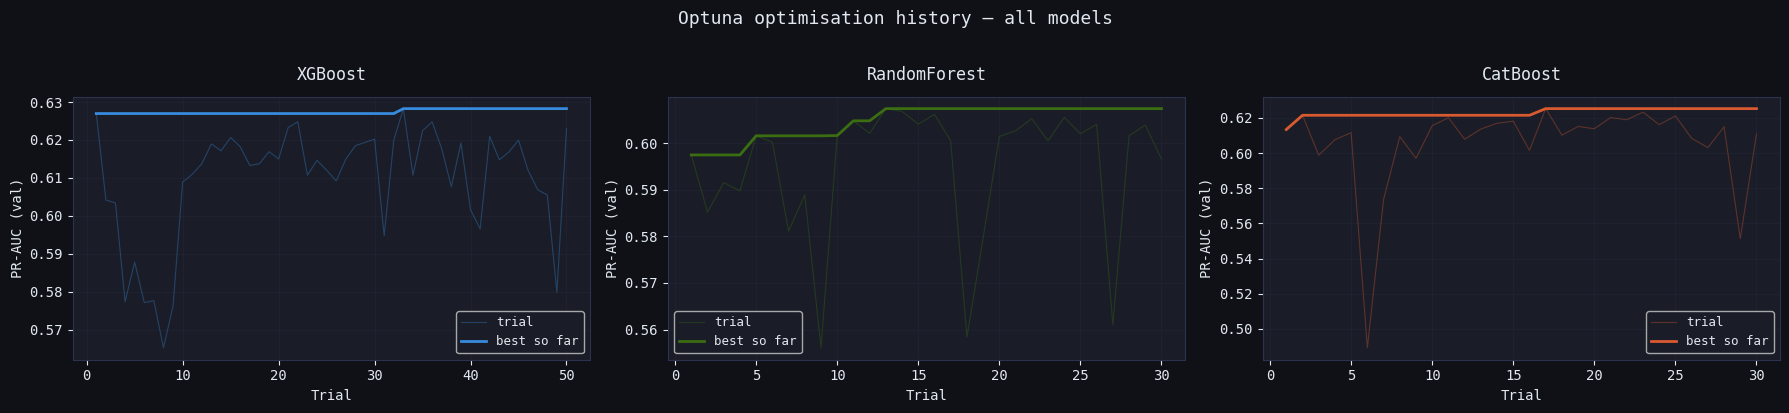

In [65]:
# ── Cell 15 | Optuna convergence plots ──────────────────────────────────────
models_dict = {"XGBoost": xgb_model, "RandomForest": rf_model, "CatBoost": cb_model}
studies_dict = {"XGBoost": xgb_study, "RandomForest": rf_study, "CatBoost": cb_study}
best_params_all = {"XGBoost": xgb_params, "RandomForest": rf_params, "CatBoost": cb_params}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
palette = {"XGBoost": "#378ADD", "RandomForest": "#3B6D11", "CatBoost": "#D85A30"}

for ax, (name, study) in zip(axes, studies_dict.items()):
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(values)
    ax.plot(range(1, len(values) + 1), values, alpha=0.35,
            color=palette[name], linewidth=0.8, label="trial")
    ax.plot(range(1, len(best_so_far) + 1), best_so_far,
            color=palette[name], linewidth=2, label="best so far")
    ax.set_title(name, fontsize=12, fontweight="medium")
    ax.set_xlabel("Trial")
    ax.set_ylabel("PR-AUC (val)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

fig.suptitle("Optuna optimisation history — all models", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()


────────────────────────────────────────────────────────────
  Evaluating: XGBoost
────────────────────────────────────────────────────────────


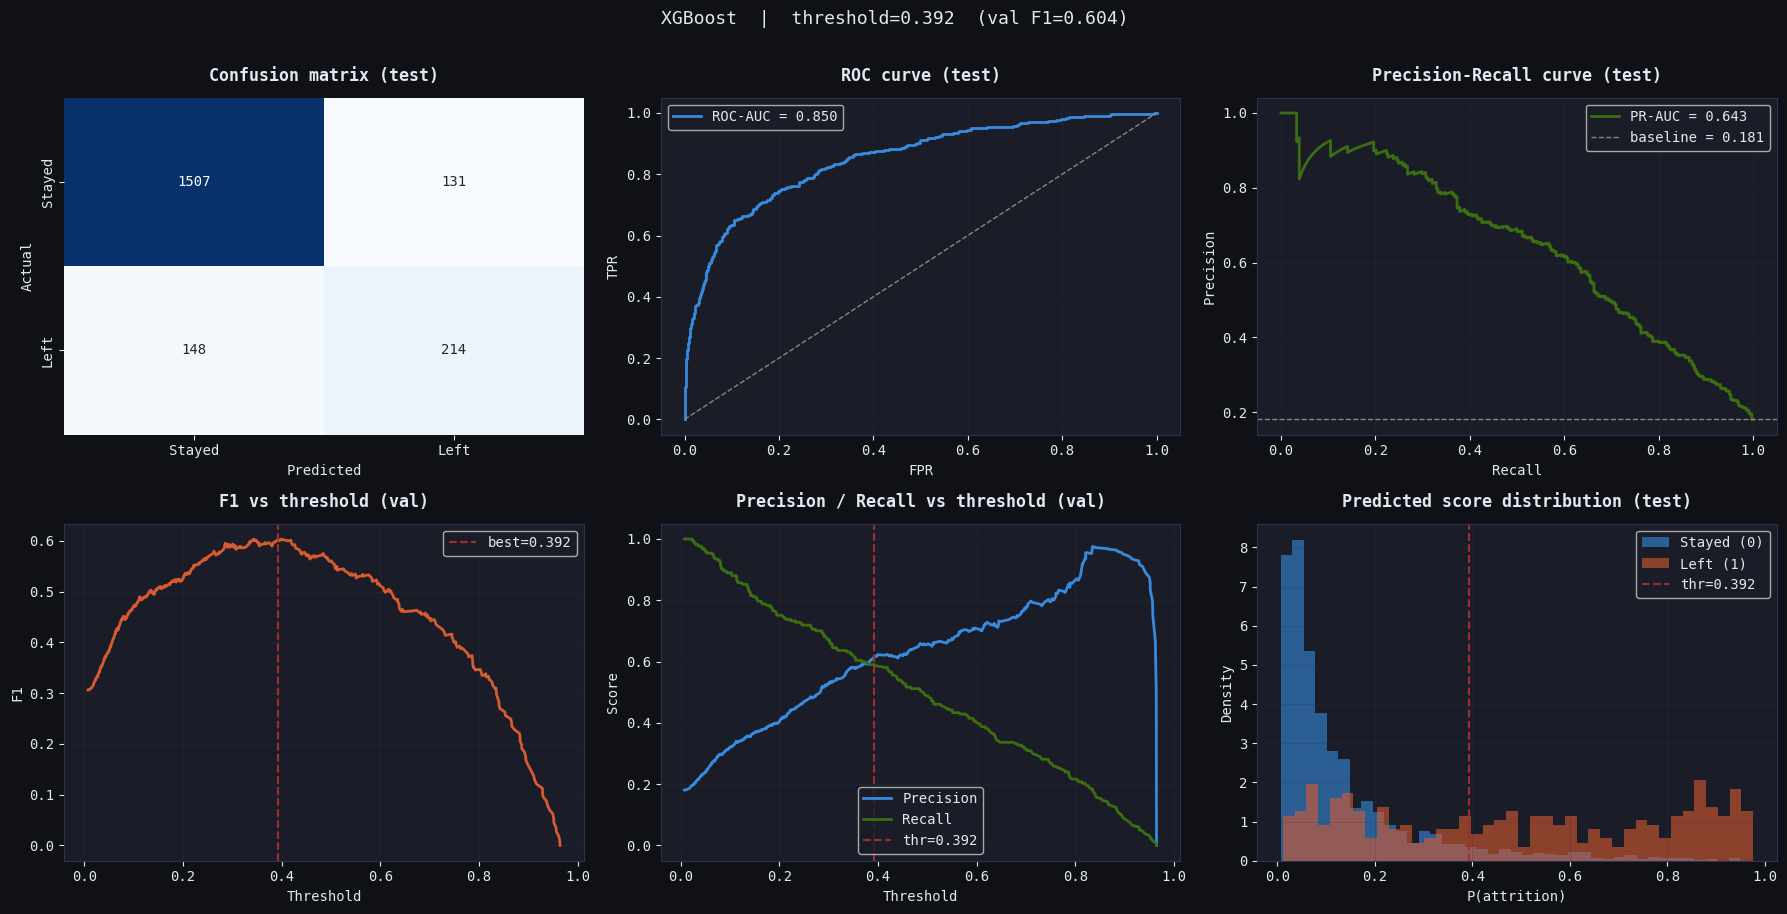

              precision    recall  f1-score   support

      Stayed       0.91      0.92      0.92      1638
        Left       0.62      0.59      0.61       362

    accuracy                           0.86      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.86      0.86      0.86      2000


────────────────────────────────────────────────────────────
  Evaluating: RandomForest
────────────────────────────────────────────────────────────


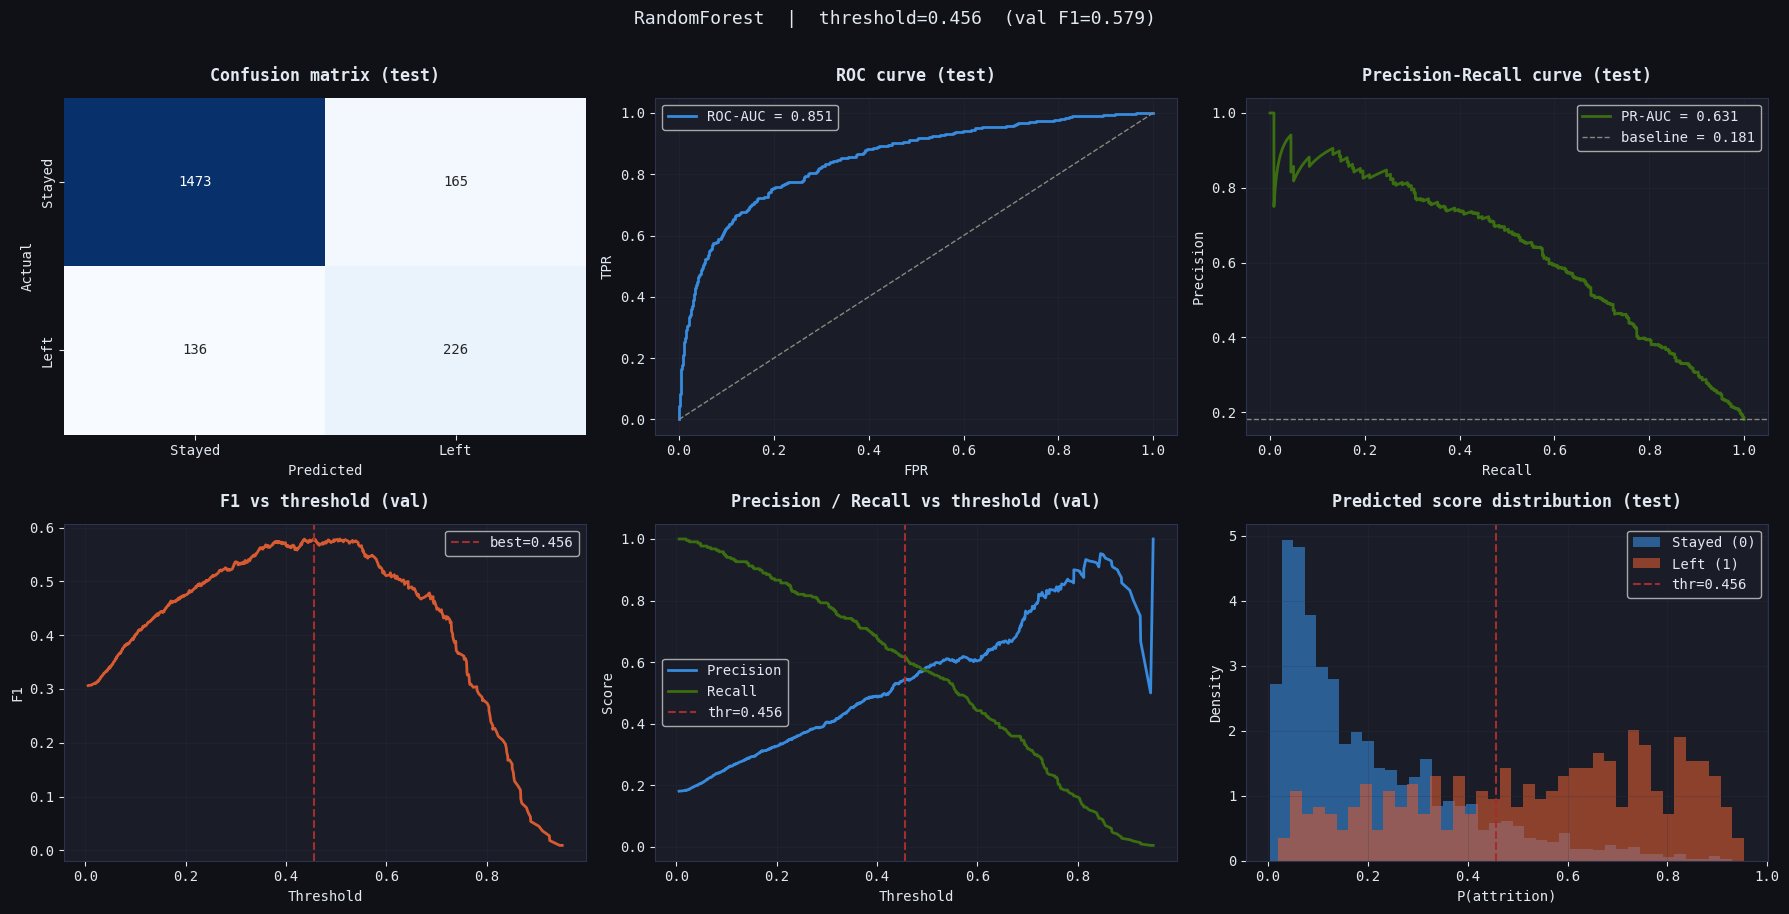

              precision    recall  f1-score   support

      Stayed       0.92      0.90      0.91      1638
        Left       0.58      0.62      0.60       362

    accuracy                           0.85      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.85      0.85      0.85      2000


────────────────────────────────────────────────────────────
  Evaluating: CatBoost
────────────────────────────────────────────────────────────


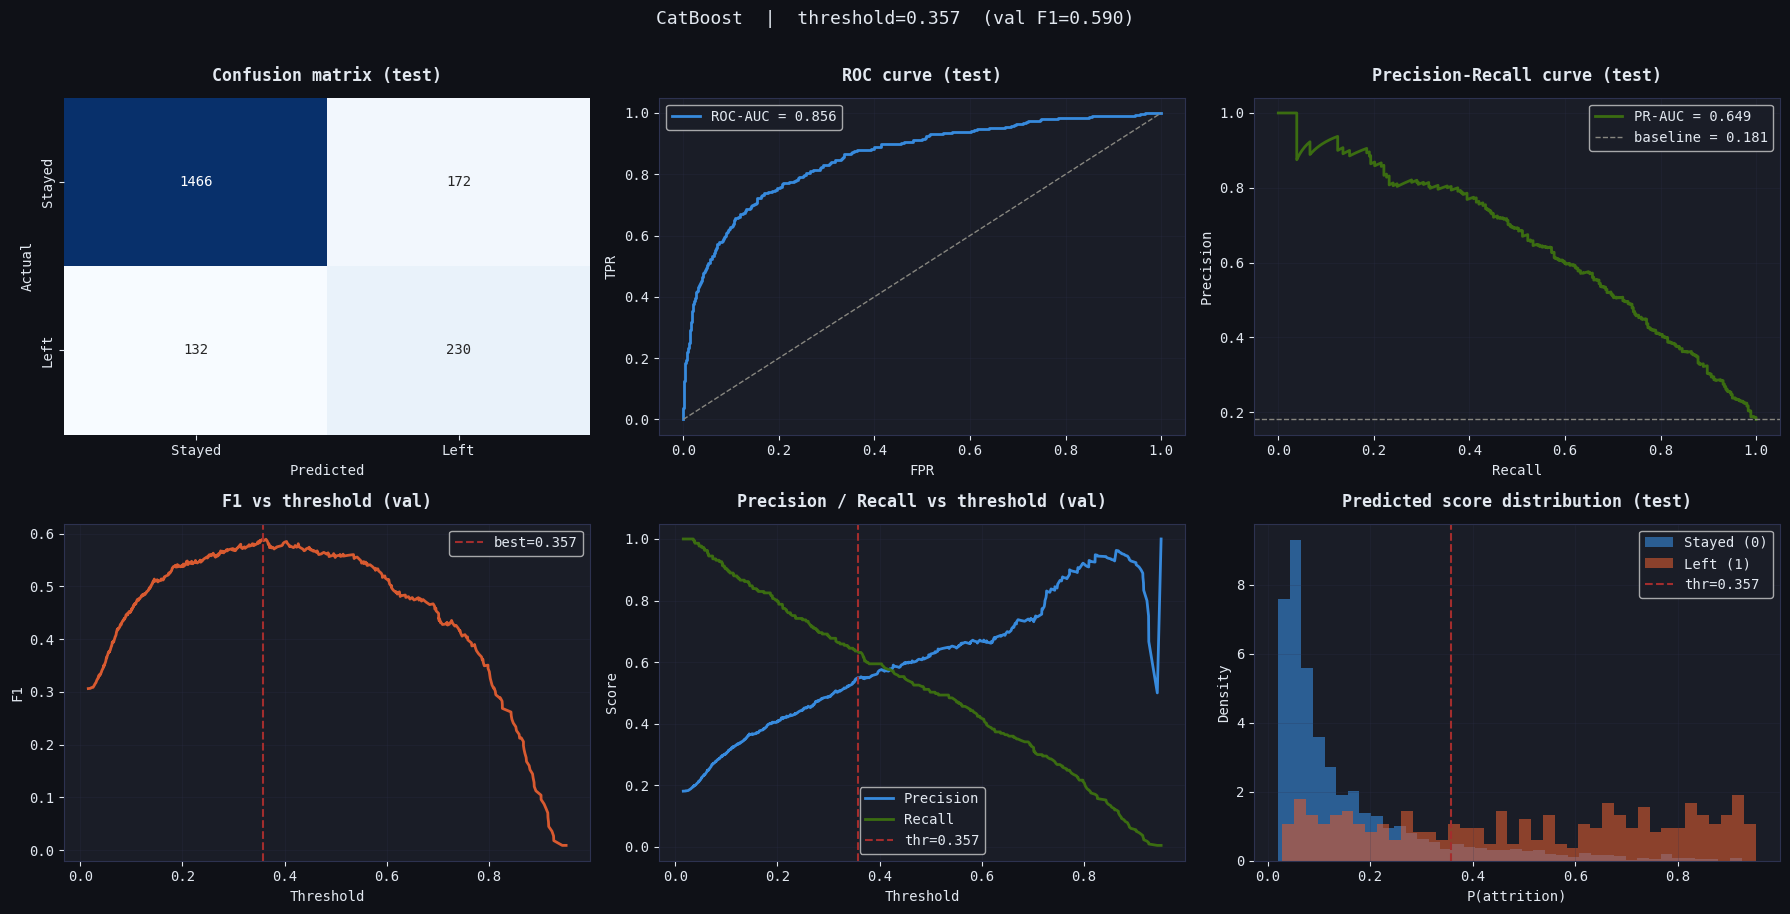

              precision    recall  f1-score   support

      Stayed       0.92      0.89      0.91      1638
        Left       0.57      0.64      0.60       362

    accuracy                           0.85      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.85      0.85      0.85      2000



In [66]:
# ── Cell 16 | Full model evaluation ─────────────────────────────────────────
# Threshold is selected on the VALIDATION set (max F1) then applied to TEST.
# This correctly simulates production: you never touch the test set for tuning.

def business_lift(y_true: np.ndarray, y_prob: np.ndarray, top_pct: float = 0.20) -> float:
    """Lift at top percentile vs. random baseline."""
    k = max(1, int(len(y_true) * top_pct))
    idx = np.argsort(-y_prob)[:k]
    return float(y_true[idx].mean() / max(y_true.mean(), 1e-9))


def find_best_threshold(
    y_true: np.ndarray, y_prob: np.ndarray
) -> Tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """Return threshold that maximises F1 on the given set."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = (2 * precision[:-1] * recall[:-1]
           / np.maximum(precision[:-1] + recall[:-1], 1e-9))
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx]), precision, recall, thresholds


def evaluate_model(
    name: str, model: Any,
    X_v: pd.DataFrame, y_v: pd.Series,
    X_te: pd.DataFrame, y_te: pd.Series,
) -> Dict[str, Any]:
    """Evaluate one model; threshold chosen on val, metrics reported on test."""

    # ── threshold selection on val ──────────────────────────────────────────
    val_prob = model.predict_proba(X_v)[:, 1]
    thr, val_best_f1, p_val, r_val, thr_val = find_best_threshold(y_v.values, val_prob)

    # ── test inference ───────────────────────────────────────────────────────
    test_prob = model.predict_proba(X_te)[:, 1]
    test_pred = (test_prob >= thr).astype(int)

    roc_auc  = roc_auc_score(y_te, test_prob)
    pr_auc   = average_precision_score(y_te, test_prob)
    f1       = f1_score(y_te, test_pred)
    brier    = brier_score_loss(y_te, test_prob)
    lift20   = business_lift(y_te.values, test_prob, top_pct=0.20)

    # ── plots ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle(f"{name}  |  threshold={thr:.3f}  (val F1={val_best_f1:.3f})",
                 fontsize=13, y=1.01)

    # Confusion matrix
    cm = confusion_matrix(y_te, test_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                ax=axes[0, 0], cbar=False,
                xticklabels=["Stayed", "Left"],
                yticklabels=["Stayed", "Left"])
    axes[0, 0].set_title("Confusion matrix (test)")
    axes[0, 0].set_xlabel("Predicted"); axes[0, 0].set_ylabel("Actual")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, test_prob)
    axes[0, 1].plot(fpr, tpr, color="#378ADD", lw=2, label=f"ROC-AUC = {roc_auc:.3f}")
    axes[0, 1].plot([0, 1], [0, 1], "--", color="#888780", lw=1)
    axes[0, 1].set_title("ROC curve (test)")
    axes[0, 1].set_xlabel("FPR"); axes[0, 1].set_ylabel("TPR")
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.25)

    # PR curve
    pr_p, pr_r, _ = precision_recall_curve(y_te, test_prob)
    baseline = y_te.mean()
    axes[0, 2].plot(pr_r, pr_p, color="#3B6D11", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
    axes[0, 2].axhline(baseline, ls="--", color="#888780", lw=1, label=f"baseline = {baseline:.3f}")
    axes[0, 2].set_title("Precision-Recall curve (test)")
    axes[0, 2].set_xlabel("Recall"); axes[0, 2].set_ylabel("Precision")
    axes[0, 2].legend(); axes[0, 2].grid(alpha=0.25)

    # F1 vs threshold (val)
    f1s_val = (2 * p_val[:-1] * r_val[:-1]
               / np.maximum(p_val[:-1] + r_val[:-1], 1e-9))
    axes[1, 0].plot(thr_val, f1s_val, color="#D85A30", lw=2)
    axes[1, 0].axvline(thr, color="#A32D2D", ls="--", lw=1.5, label=f"best={thr:.3f}")
    axes[1, 0].set_title("F1 vs threshold (val)")
    axes[1, 0].set_xlabel("Threshold"); axes[1, 0].set_ylabel("F1")
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.25)

    # Precision / Recall vs threshold (val)
    axes[1, 1].plot(thr_val, p_val[:-1], color="#378ADD", lw=2, label="Precision")
    axes[1, 1].plot(thr_val, r_val[:-1], color="#3B6D11", lw=2, label="Recall")
    axes[1, 1].axvline(thr, color="#A32D2D", ls="--", lw=1.5, label=f"thr={thr:.3f}")
    axes[1, 1].set_title("Precision / Recall vs threshold (val)")
    axes[1, 1].set_xlabel("Threshold"); axes[1, 1].set_ylabel("Score")
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.25)

    # Score distribution
    axes[1, 2].hist(test_prob[y_te == 0], bins=40, alpha=0.6,
                    color="#378ADD", label="Stayed (0)", density=True)
    axes[1, 2].hist(test_prob[y_te == 1], bins=40, alpha=0.6,
                    color="#D85A30", label="Left (1)", density=True)
    axes[1, 2].axvline(thr, color="#A32D2D", ls="--", lw=1.5, label=f"thr={thr:.3f}")
    axes[1, 2].set_title("Predicted score distribution (test)")
    axes[1, 2].set_xlabel("P(attrition)"); axes[1, 2].set_ylabel("Density")
    axes[1, 2].legend(); axes[1, 2].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name.lower()}_eval.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(classification_report(y_te, test_pred, target_names=["Stayed", "Left"]))

    return dict(
        model         = name,
        threshold     = round(thr, 4),
        val_best_f1   = round(val_best_f1, 4),
        test_roc_auc  = round(roc_auc, 4),
        test_pr_auc   = round(pr_auc, 4),
        test_f1       = round(f1, 4),
        test_brier    = round(brier, 4),
        lift_at_20pct = round(lift20, 4),
    )


evaluation_rows = []
for name, model in models_dict.items():
    print(f"\n{'─'*60}")
    print(f"  Evaluating: {name}")
    print(f"{'─'*60}")
    row = evaluate_model(name, model, X_val, y_val, X_test, y_test)
    evaluation_rows.append(row)

In [67]:
# ── Cell 17 | Comparison table & winner ─────────────────────────────────────
evaluation_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(
    evaluation_df.style
    .highlight_max(axis=0, subset=["test_roc_auc", "test_pr_auc", "test_f1", "lift_at_20pct"],
                   props="background-color: #EAF3DE; color: #27500A; font-weight: 500;")
    .highlight_min(axis=0, subset=["test_brier"],
                   props="background-color: #EAF3DE; color: #27500A; font-weight: 500;")
    .format({c: "{:.4f}" for c in evaluation_df.select_dtypes(float).columns})
    .set_caption("Model comparison — test set (green = best per metric)")
)

# Winner: primary sort ROC-AUC, secondary PR-AUC, tertiary F1
winner_row = (
    evaluation_df
    .sort_values(["test_roc_auc", "test_pr_auc", "test_f1"], ascending=False)
    .iloc[0]
)
WINNER_MODEL_NAME = winner_row["model"]
WINNER_MODEL      = models_dict[WINNER_MODEL_NAME]
WINNER_THRESHOLD  = winner_row["threshold"]

print(f"\n✓ Winner: {WINNER_MODEL_NAME}")
print(f"  ROC-AUC={winner_row['test_roc_auc']:.4f} | "
      f"PR-AUC={winner_row['test_pr_auc']:.4f} | "
      f"F1={winner_row['test_f1']:.4f} | "
      f"Brier={winner_row['test_brier']:.4f} | "
      f"Lift@20%={winner_row['lift_at_20pct']:.2f}x")

,model,threshold,val_best_f1,test_roc_auc,test_pr_auc,test_f1,test_brier,lift_at_20pct
0,CatBoost,0.3572,0.5897,0.8563,0.6492,0.6021,0.0994,3.1630
1,RandomForest,0.4561,0.5788,0.8511,0.6307,0.6003,0.1094,3.1630
2,XGBoost,0.3924,0.6038,0.8501,0.6434,0.6054,0.0999,3.1768



✓ Winner: CatBoost
  ROC-AUC=0.8563 | PR-AUC=0.6492 | F1=0.6021 | Brier=0.0994 | Lift@20%=3.16x


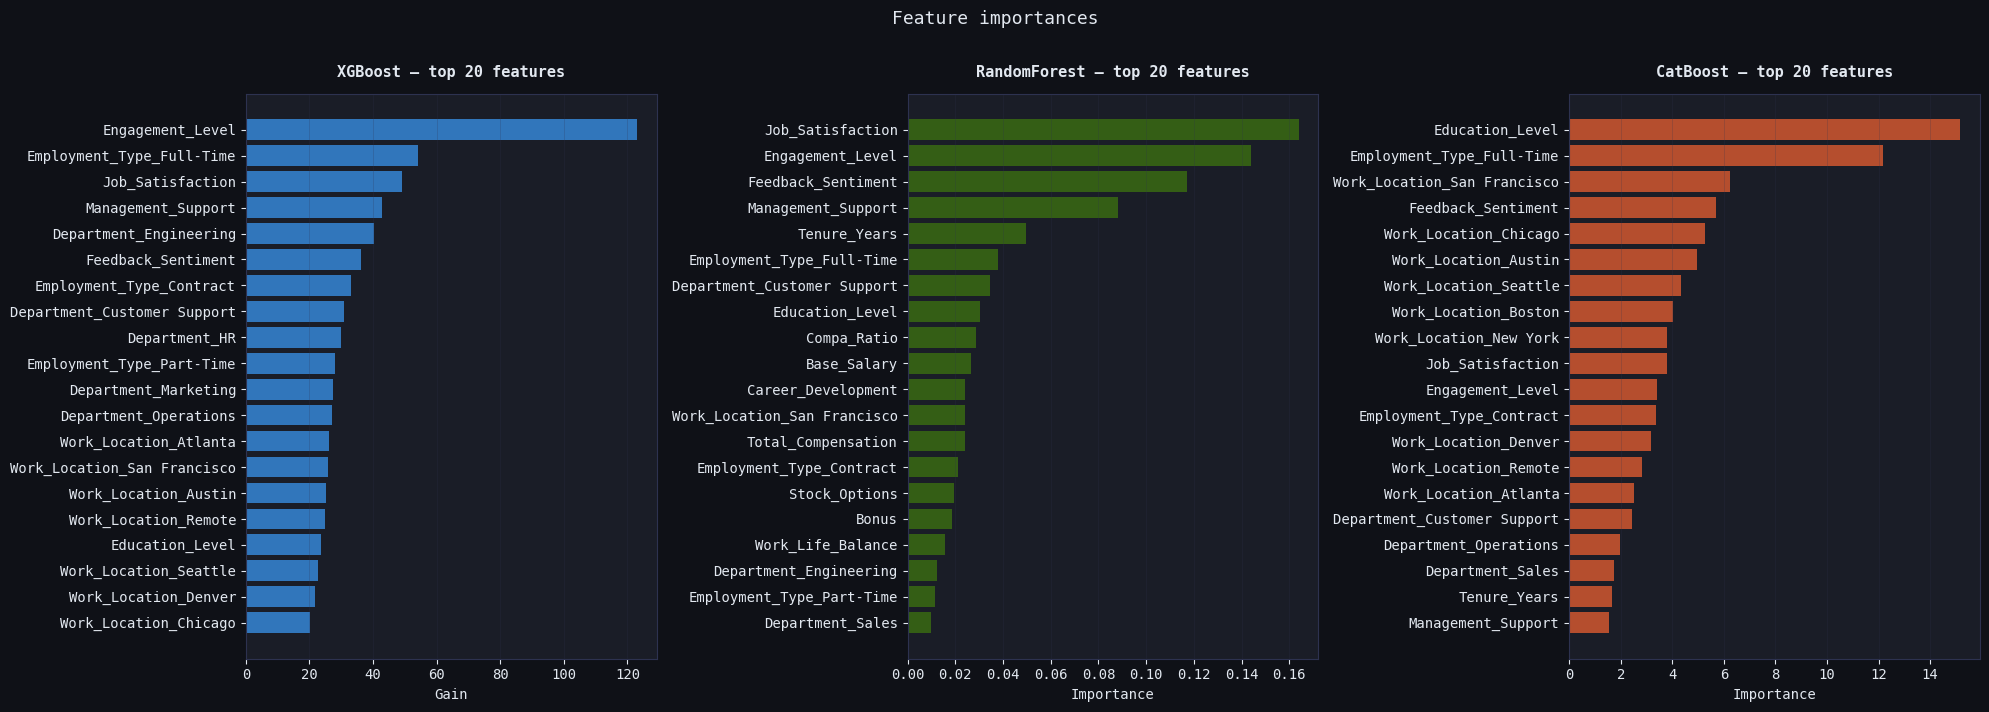

In [68]:
# ── Cell 18 | Feature importance ────────────────────────────────────────────
TOP_N = 20
feature_names = X_train_sm.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = {"XGBoost": "#378ADD", "RandomForest": "#3B6D11", "CatBoost": "#D85A30"}

for ax, (name, model) in zip(axes, models_dict.items()):

    if name == "XGBoost":
        imp = model.get_booster().get_score(importance_type="gain")
        imp_series = pd.Series(imp).reindex(feature_names).fillna(0)

    elif name == "RandomForest":
        imp_series = pd.Series(model.feature_importances_, index=feature_names)

    elif name == "CatBoost":
        imp_series = pd.Series(
            model.get_feature_importance(),
            index=feature_names,
        )

    top = imp_series.nlargest(TOP_N).sort_values()
    ax.barh(top.index, top.values, color=colors[name], alpha=0.82)
    ax.set_title(f"{name} — top {TOP_N} features", fontsize=11)
    ax.set_xlabel("Importance" if name != "XGBoost" else "Gain")
    ax.grid(axis="x", alpha=0.25)

plt.suptitle("Feature importances", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

In [69]:
# ── Cell 19 | Save models & artefacts ───────────────────────────────────────
for name, model in models_dict.items():
    path = OUTPUT_DIR / f"{name.lower()}_best_model.joblib"
    joblib.dump(model, path)
    print(f"Saved {name} → {path}")

# Save all best params as JSON
with open(OUTPUT_DIR / "best_params_all.json", "w") as f:
    serialisable = {}
    for name, params in best_params_all.items():
        serialisable[name] = {
            k: (float(v) if isinstance(v, (np.floating, float)) else
                int(v)   if isinstance(v, (np.integer, int))   else v)
            for k, v in params.items()
        }
    json.dump(serialisable, f, indent=2)
print(f"Saved best_params_all.json → {OUTPUT_DIR}")

# Save evaluation table
evaluation_df.to_csv(OUTPUT_DIR / "model_evaluation.csv", index=False)
print(f"Saved model_evaluation.csv → {OUTPUT_DIR}")

# Save winner threshold (needed at inference time)
winner_meta = {
    "winner_model": WINNER_MODEL_NAME,
    "threshold": float(WINNER_THRESHOLD),
    "val_best_f1": float(winner_row["val_best_f1"]),
}
with open(OUTPUT_DIR / "winner_meta.json", "w") as f:
    json.dump(winner_meta, f, indent=2)
print(f"Saved winner_meta.json → {OUTPUT_DIR}")

print("\nAll artefacts saved.")
print(f"Winner model file: outputs/{WINNER_MODEL_NAME.lower()}_best_model.joblib")

Saved XGBoost → outputs/xgboost_best_model.joblib
Saved RandomForest → outputs/randomforest_best_model.joblib
Saved CatBoost → outputs/catboost_best_model.joblib
Saved best_params_all.json → outputs
Saved model_evaluation.csv → outputs
Saved winner_meta.json → outputs

All artefacts saved.
Winner model file: outputs/catboost_best_model.joblib


⚠ master_df not found; using model_df from pipeline


Dataset: 10,000 employees | 1,808 left (18.1%) | 8,192 stayed


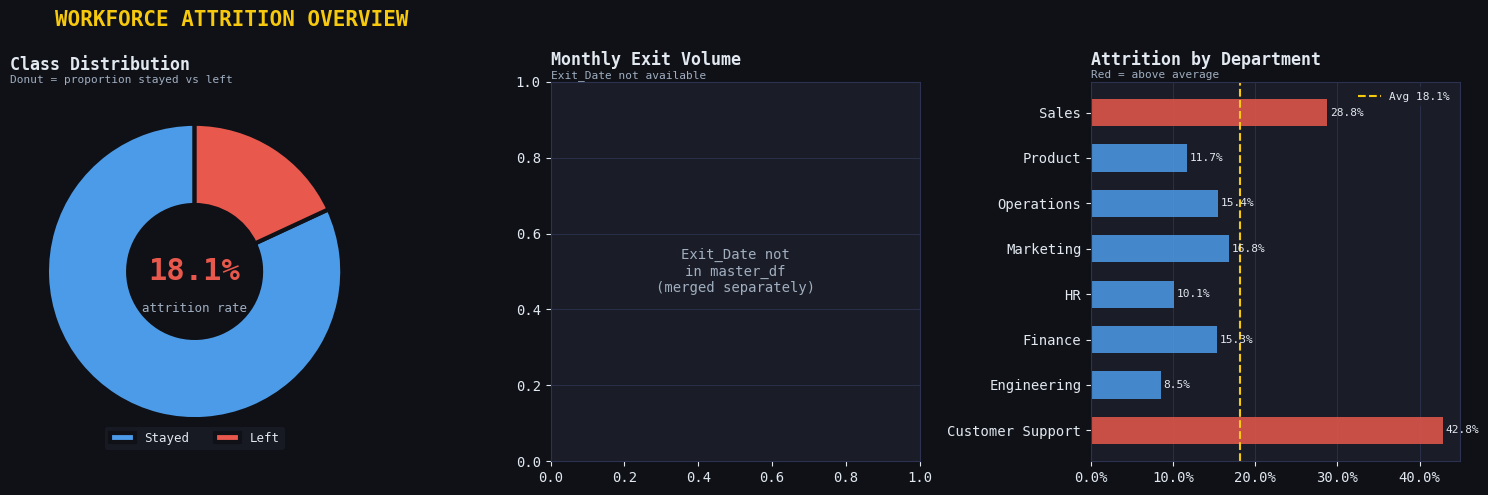

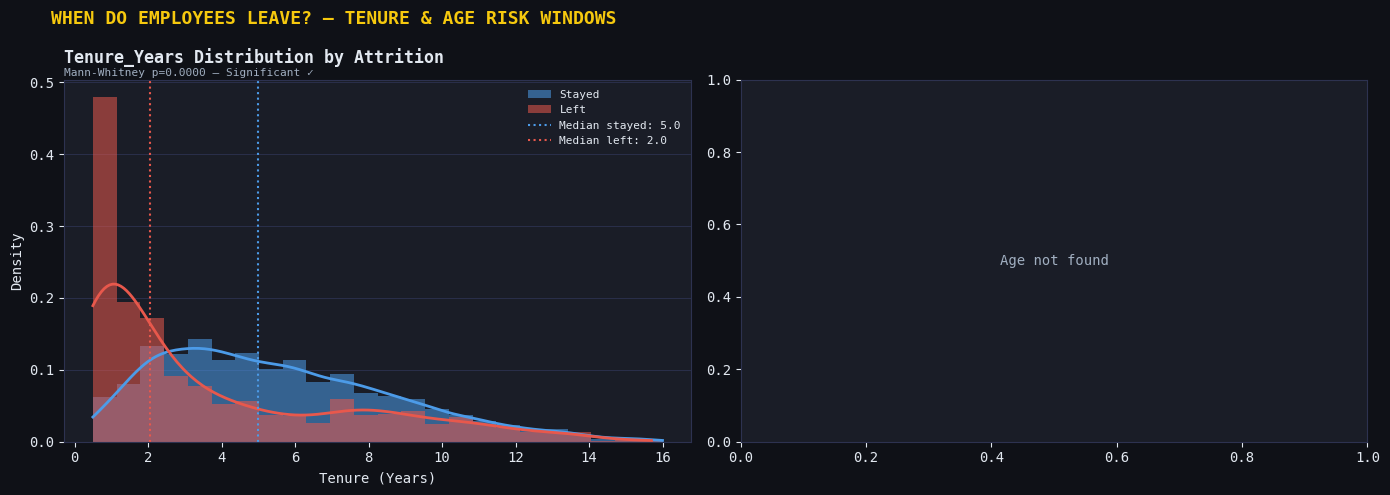

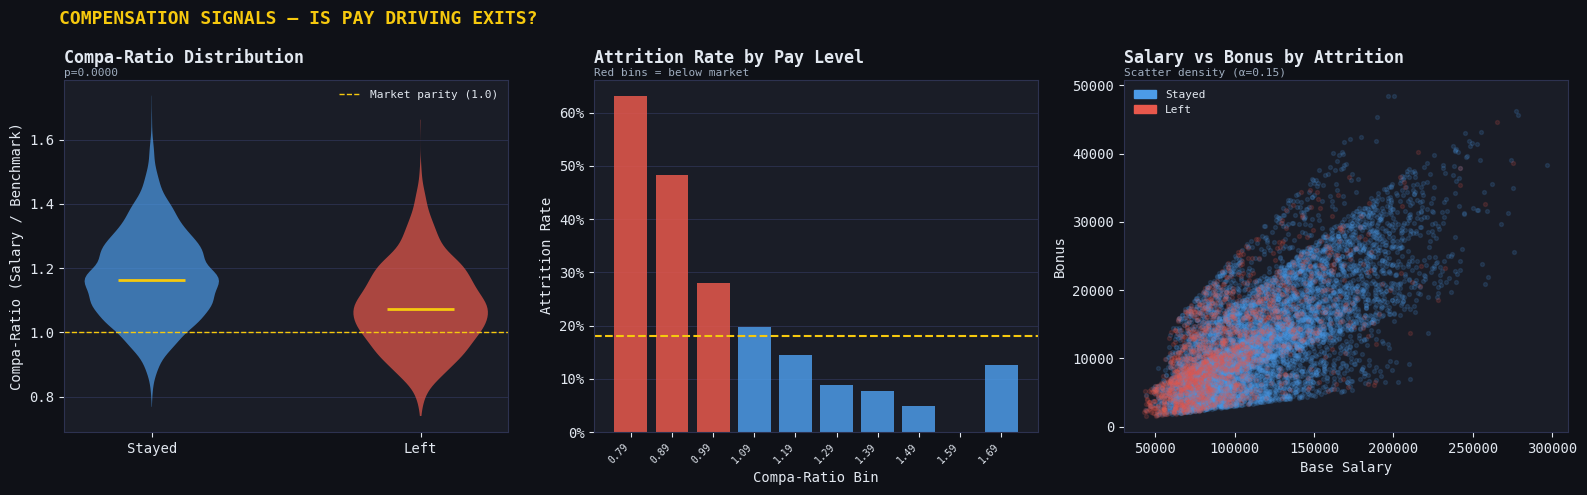

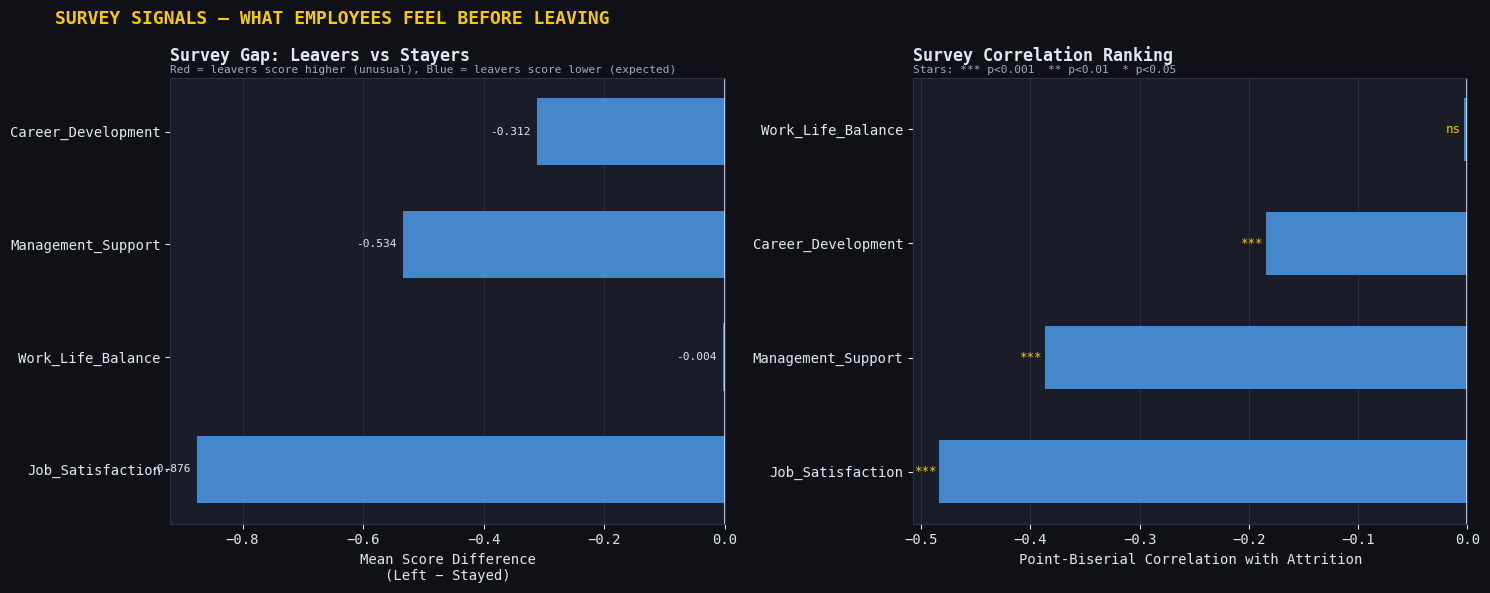

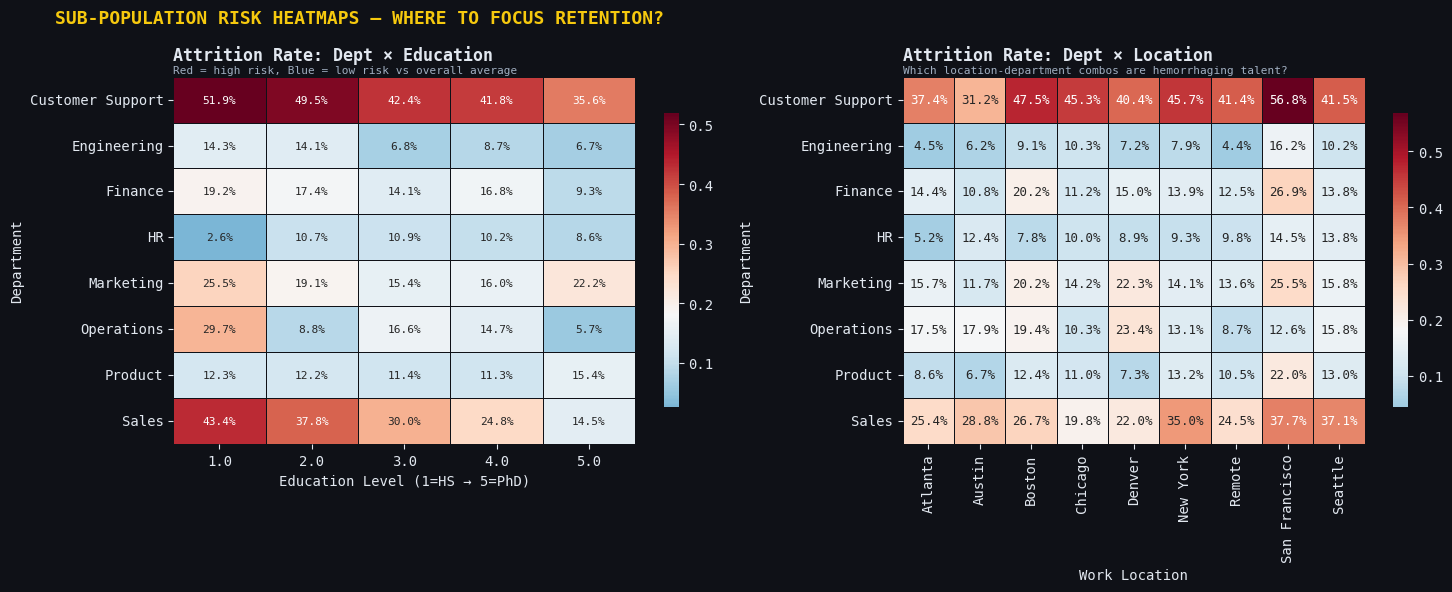

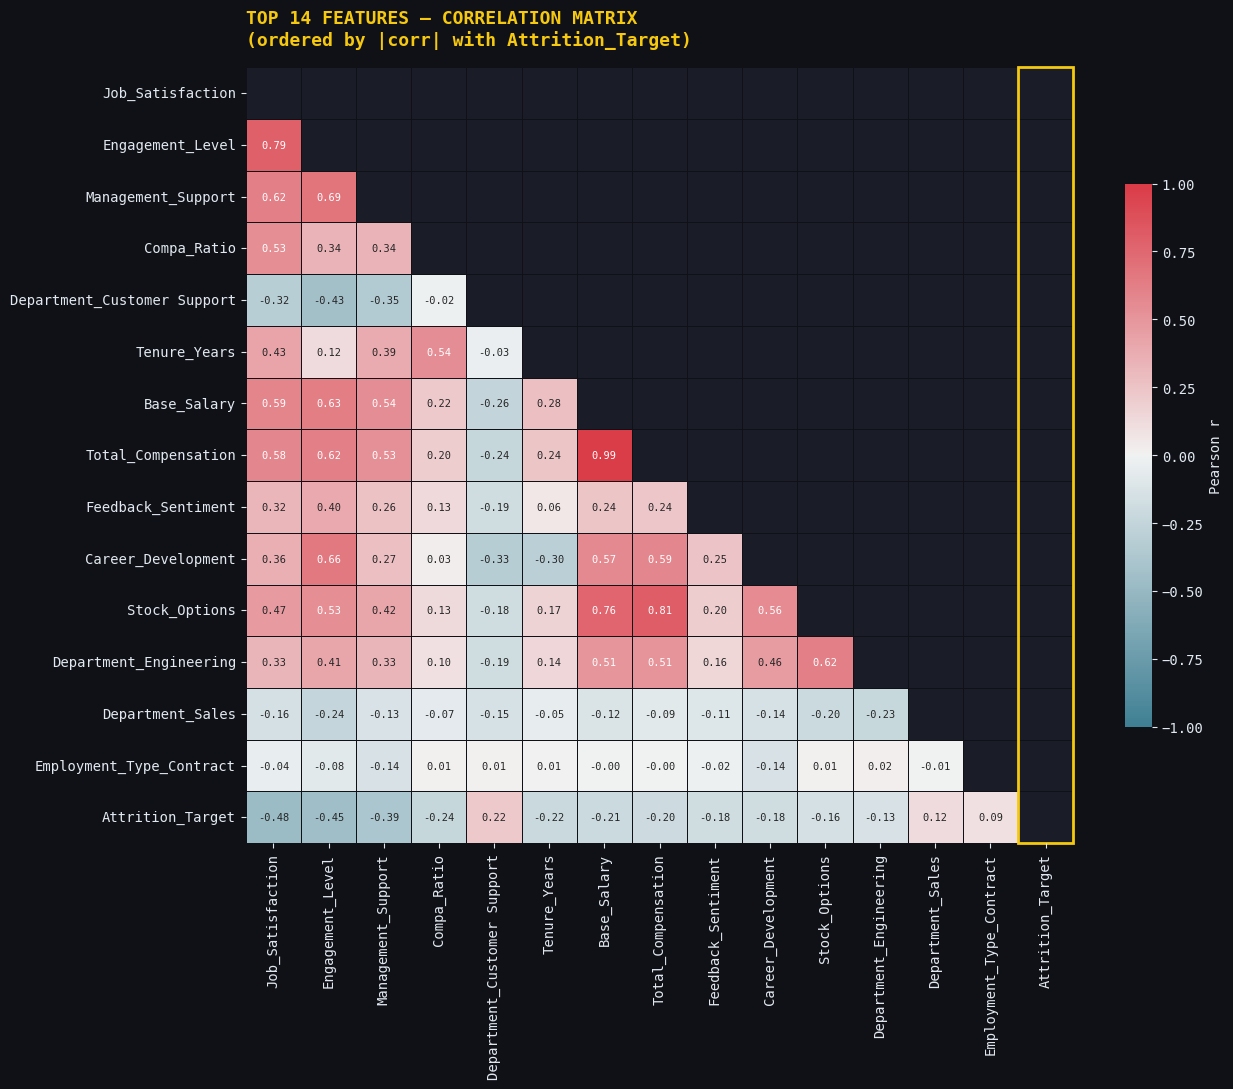

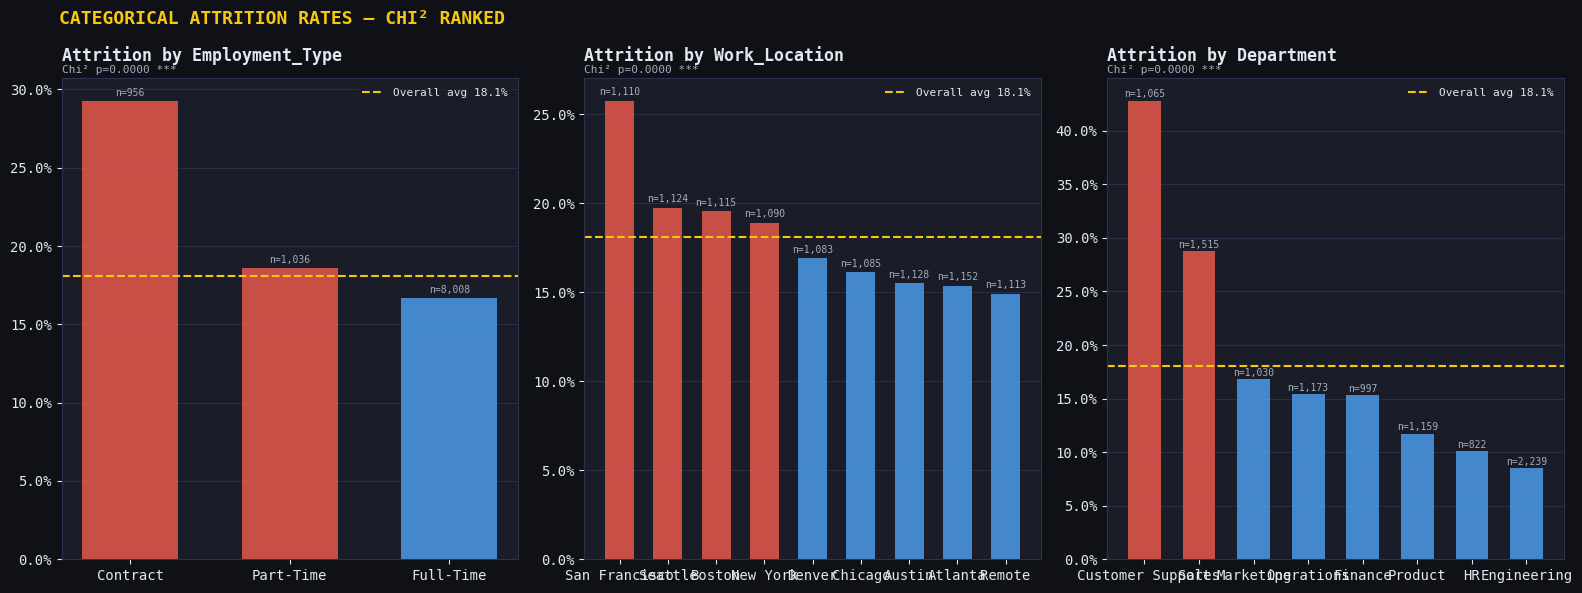

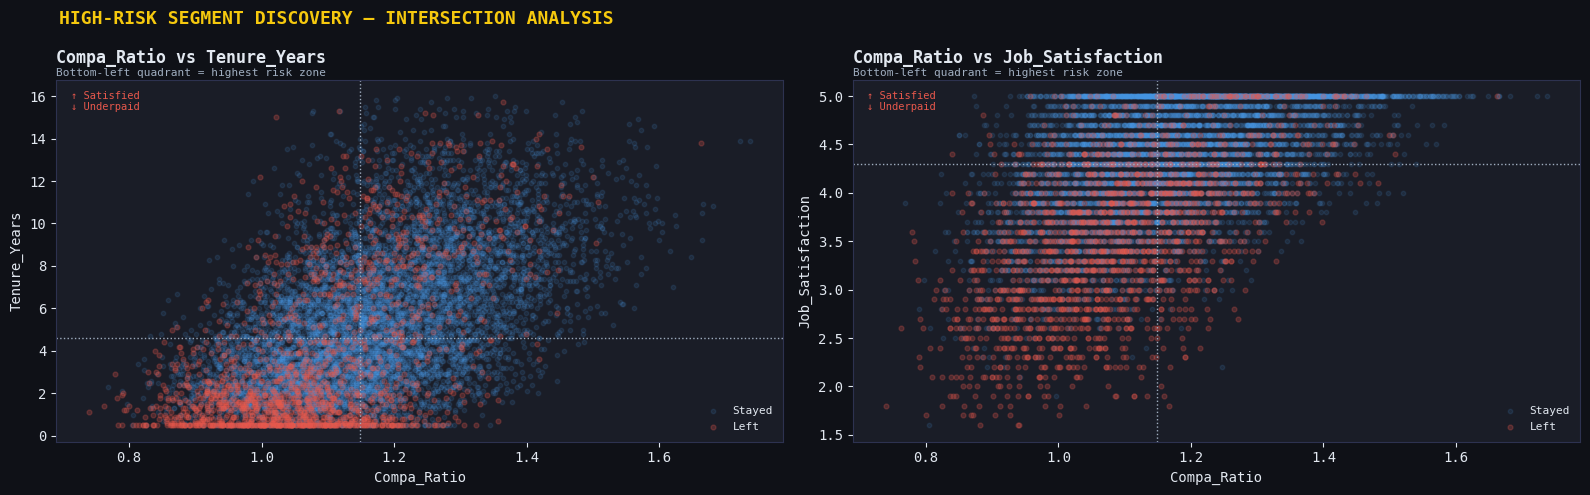


✅ All EDA plots saved to outputs/
Key findings summary:
  • Attrition rate: 18.1%
  • Most correlated numeric feature: Job_Satisfaction (r=0.483)
  • Strongest survey signal: Job_Satisfaction


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 0 — Load master dataset  (adjust path as needed)
# ══════════════════════════════════════════════════════════════════════════════
# Assumes the pipeline Stage-1 merge has run and produced master_df.
# If not, merge here:
#   master_df = pd.read_csv("outputs/master_dataset.csv")
# For standalone use, point to your merged CSV.

# Try to use master_df if it exists; fall back to model_df or df
if 'master_df' not in locals():
    if 'model_df' in locals():
        print("⚠ master_df not found; using model_df from pipeline")
        df = model_df.copy()
    elif 'df' in locals():
        print("⚠ master_df not found; using df from pipeline")
        df = df.copy()
    else:
        # Try loading from CSV
        import os
        csv_path = "outputs/master_dataset.csv"
        if os.path.exists(csv_path):
            print(f"Loading from {csv_path}...")
            df = pd.read_csv(csv_path)
        else:
            raise FileNotFoundError(
                f"❌ Could not find master_df, model_df, or {csv_path}. "
                "Run the preprocessing pipeline first."
            )
else:
    df = master_df.copy()

TARGET = "Attrition_Target"
if TARGET not in df.columns:
    raise ValueError(f"❌ Target column '{TARGET}' not found in dataframe. "
                     f"Available columns: {list(df.columns)}")

attrition_rate = df[TARGET].mean()
n_total = len(df)
n_left  = df[TARGET].sum()
n_stay  = n_total - n_left

print(f"Dataset: {n_total:,} employees | {n_left:,} left ({attrition_rate:.1%}) | {n_stay:,} stayed")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Class Balance + Context
# Question: How severe is imbalance? What's the raw business impact?
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)
fig.suptitle("WORKFORCE ATTRITION OVERVIEW", color=ACCENT,
             fontsize=15, fontweight="bold", x=0.04, ha="left")

# Donut
ax = axes[0]
sizes  = [n_stay, n_left]
colors = [STAY_COLOR, LEAVE_COLOR]
wedges, _ = ax.pie(sizes, colors=colors, startangle=90,
                   wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=3))
ax.text(0, 0,  f"{attrition_rate:.1%}", ha="center", va="center",
        fontsize=22, fontweight="bold", color=LEAVE_COLOR)
ax.text(0, -0.25, "attrition rate", ha="center", va="center",
        fontsize=9, color=NEUTRAL)
styled_title(ax, "Class Distribution", "Donut = proportion stayed vs left")
ax.legend(["Stayed", "Left"], loc="lower center", ncol=2,
          facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=9)

# Monthly run-rate bar (simulated if exit_date missing)
ax = axes[1]
if "Exit_Date" in df.columns:
    exits = (pd.to_datetime(df.loc[df[TARGET]==1, "Exit_Date"])
               .dt.to_period("M").value_counts().sort_index())
    ax.bar(range(len(exits)), exits.values, color=LEAVE_COLOR, alpha=0.8, width=0.7)
    ax.set_xticks(range(0, len(exits), max(1, len(exits)//6)))
    ax.set_xticklabels([str(exits.index[i]) for i in range(0, len(exits), max(1, len(exits)//6))],
                       rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Exits")
    styled_title(ax, "Monthly Exit Volume", "When are people leaving?")
else:
    ax.text(0.5, 0.5, "Exit_Date not\nin master_df\n(merged separately)",
            ha="center", va="center", transform=ax.transAxes, color=NEUTRAL, fontsize=10)
    styled_title(ax, "Monthly Exit Volume", "Exit_Date not available")
ax.yaxis.grid(True); ax.set_axisbelow(True)

# Department attrition rates
ax = axes[2]
dept_cols = [c for c in df.columns if c.startswith("Department_")]
if dept_cols:
    dept_rates = {}
    for col in dept_cols:
        name = col.replace("Department_", "")
        mask = df[col] == 1
        if mask.sum() > 10:
            dept_rates[name] = df.loc[mask, TARGET].mean()
    if dept_rates:
        names = list(dept_rates.keys())
        rates = list(dept_rates.values())
        colors_d = [LEAVE_COLOR if r > attrition_rate else STAY_COLOR for r in rates]
        bars = ax.barh(names, rates, color=colors_d, alpha=0.85, height=0.6)
        ax.axvline(attrition_rate, color=ACCENT, lw=1.5, ls="--", label=f"Avg {attrition_rate:.1%}")
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        for bar, r in zip(bars, rates):
            ax.text(r + 0.003, bar.get_y() + bar.get_height()/2,
                    f"{r:.1%}", va="center", fontsize=8)
        ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
        styled_title(ax, "Attrition by Department", "Red = above average")
ax.xaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, "01_overview")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Tenure & Age distributions split by attrition
# Question: At what tenure/age is risk highest?
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("WHEN DO EMPLOYEES LEAVE? — TENURE & AGE RISK WINDOWS",
             color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

for ax, col, xlabel in zip(axes,
                            ["Tenure_Years", "Age"],
                            ["Tenure (Years)", "Age"]):
    if col not in df.columns:
        ax.text(0.5, 0.5, f"{col} not found", ha="center", va="center",
                transform=ax.transAxes, color=NEUTRAL)
        continue
    stayed = df.loc[df[TARGET]==0, col].dropna()
    left   = df.loc[df[TARGET]==1, col].dropna()
    bins   = np.linspace(df[col].min(), df[col].max(), 25)
    ax.hist(stayed, bins=bins, color=STAY_COLOR, alpha=0.55, label="Stayed", density=True)
    ax.hist(left,   bins=bins, color=LEAVE_COLOR, alpha=0.55, label="Left",   density=True)
    # KDE overlay
    for data, color in [(stayed, STAY_COLOR), (left, LEAVE_COLOR)]:
        kde = stats.gaussian_kde(data)
        x   = np.linspace(data.min(), data.max(), 200)
        ax.plot(x, kde(x), color=color, lw=2)
    # Median lines
    ax.axvline(stayed.median(), color=STAY_COLOR, ls=":", lw=1.5,
               label=f"Median stayed: {stayed.median():.1f}")
    ax.axvline(left.median(),   color=LEAVE_COLOR, ls=":", lw=1.5,
               label=f"Median left: {left.median():.1f}")
    ax.set_xlabel(xlabel); ax.set_ylabel("Density")
    ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    stat, pval = stats.mannwhitneyu(stayed, left, alternative="two-sided")
    styled_title(ax, f"{col} Distribution by Attrition",
                 f"Mann-Whitney p={pval:.4f} — {'Significant ✓' if pval<0.05 else 'Not significant'}")

plt.tight_layout()
save_fig(fig, "02_tenure_age_risk")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Compensation Risk: Compa-Ratio & Salary vs Attrition
# Question: Are underpaid employees more likely to leave?
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.suptitle("COMPENSATION SIGNALS — IS PAY DRIVING EXITS?",
             color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

# Compa-ratio violin
ax = axes[0]
if "Compa_Ratio" in df.columns:
    data_plot = [df.loc[df[TARGET]==0, "Compa_Ratio"].dropna(),
                 df.loc[df[TARGET]==1, "Compa_Ratio"].dropna()]
    parts = ax.violinplot(data_plot, positions=[0,1], showmedians=True,
                          showextrema=False)
    for pc, c in zip(parts["bodies"], [STAY_COLOR, LEAVE_COLOR]):
        pc.set_facecolor(c); pc.set_alpha(0.7)
    parts["cmedians"].set_color(ACCENT); parts["cmedians"].set_linewidth(2)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Stayed","Left"])
    ax.axhline(1.0, color=ACCENT, ls="--", lw=1, label="Market parity (1.0)")
    ax.set_ylabel("Compa-Ratio (Salary / Benchmark)")
    ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
    t_stat, pval = stats.mannwhitneyu(*data_plot, alternative="two-sided")
    styled_title(ax, "Compa-Ratio Distribution", f"p={pval:.4f}")
    ax.yaxis.grid(True); ax.set_axisbelow(True)

# Compa-ratio binned attrition rate
ax = axes[1]
if "Compa_Ratio" in df.columns:
    df["_cr_bin"] = pd.cut(df["Compa_Ratio"], bins=10)
    cr_agg = df.groupby("_cr_bin")[TARGET].agg(["mean","count"]).reset_index()
    cr_agg = cr_agg[cr_agg["count"] > 5]
    midpoints = [iv.mid for iv in cr_agg["_cr_bin"]]
    bar_colors = [LEAVE_COLOR if m < 1.0 else STAY_COLOR for m in midpoints]
    bars = ax.bar(range(len(cr_agg)), cr_agg["mean"], color=bar_colors, alpha=0.85)
    ax.axhline(attrition_rate, color=ACCENT, ls="--", lw=1.5)
    ax.set_xticks(range(len(cr_agg)))
    ax.set_xticklabels([f"{m:.2f}" for m in midpoints], rotation=45, ha="right", fontsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel("Compa-Ratio Bin"); ax.set_ylabel("Attrition Rate")
    styled_title(ax, "Attrition Rate by Pay Level", "Red bins = below market")
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    df.drop(columns=["_cr_bin"], inplace=True)

# Bonus vs attrition scatter-density
ax = axes[2]
bonus_col = next((c for c in ["Bonus_Pct","Bonus","Bonus_Amount"] if c in df.columns), None)
if bonus_col:
    for label, color in [(0, STAY_COLOR), (1, LEAVE_COLOR)]:
        subset = df[df[TARGET]==label]
        ax.scatter(subset["Base_Salary"] if "Base_Salary" in df.columns else subset.index,
                   subset[bonus_col],
                   c=color, alpha=0.15, s=8, rasterized=True)
    ax.set_xlabel("Base Salary"); ax.set_ylabel(bonus_col)
    patches = [mpatches.Patch(color=STAY_COLOR, label="Stayed"),
               mpatches.Patch(color=LEAVE_COLOR, label="Left")]
    ax.legend(handles=patches, facecolor=CARD_BG, edgecolor="none",
              labelcolor=TEXT, fontsize=8)
    styled_title(ax, "Salary vs Bonus by Attrition", "Scatter density (α=0.15)")
else:
    ax.text(0.5,0.5,"Bonus column\nnot found", ha="center", va="center",
            transform=ax.transAxes, color=NEUTRAL)

plt.tight_layout()
save_fig(fig, "03_compensation_risk")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Survey Score Profiles (radar + diverging bars)
# Question: Which satisfaction dimensions predict attrition?
# ══════════════════════════════════════════════════════════════════════════════
SURVEY_COLS = [c for c in ["Job_Satisfaction","Work_Life_Balance","Engagement",
                             "Management_Support","Career_Development",
                             "Sentiment_Score"]
               if c in df.columns]

if SURVEY_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)
    fig.suptitle("SURVEY SIGNALS — WHAT EMPLOYEES FEEL BEFORE LEAVING",
                 color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

    # Diverging mean difference bar
    ax = axes[0]
    means = df.groupby(TARGET)[SURVEY_COLS].mean()
    diff  = means.loc[1] - means.loc[0]   # left minus stayed
    cols  = [LEAVE_COLOR if d > 0 else STAY_COLOR for d in diff.values]
    ax.barh(diff.index, diff.values, color=cols, alpha=0.85, height=0.6)
    ax.axvline(0, color=TEXT, lw=1.2)
    for i, (name, val) in enumerate(diff.items()):
        ax.text(val + (0.01 if val >= 0 else -0.01), i,
                f"{val:+.3f}", va="center",
                ha="left" if val >= 0 else "right", fontsize=8)
    ax.set_xlabel("Mean Score Difference\n(Left − Stayed)")
    styled_title(ax, "Survey Gap: Leavers vs Stayers",
                 "Red = leavers score higher (unusual), Blue = leavers score lower (expected)")
    ax.xaxis.grid(True); ax.set_axisbelow(True)

    # Point-biserial correlation with significance stars
    ax = axes[1]
    corrs, pvals, labels = [], [], []
    for col in SURVEY_COLS:
        r, p = pointbiserialr(df[TARGET], df[col].fillna(df[col].median()))
        corrs.append(r); pvals.append(p); labels.append(col)
    sort_idx = np.argsort(corrs)
    corrs_s  = [corrs[i] for i in sort_idx]
    labels_s = [labels[i] for i in sort_idx]
    pvals_s  = [pvals[i] for i in sort_idx]
    bar_colors = [LEAVE_COLOR if c > 0 else STAY_COLOR for c in corrs_s]
    bars = ax.barh(labels_s, corrs_s, color=bar_colors, alpha=0.85, height=0.55)
    ax.axvline(0, color=TEXT, lw=1.2)
    for i, (r, p) in enumerate(zip(corrs_s, pvals_s)):
        star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.text(r + (0.003 if r >= 0 else -0.003), i, star,
                va="center", ha="left" if r >= 0 else "right",
                fontsize=9, color=ACCENT)
    ax.set_xlabel("Point-Biserial Correlation with Attrition")
    styled_title(ax, "Survey Correlation Ranking",
                 "Stars: *** p<0.001  ** p<0.01  * p<0.05")
    ax.xaxis.grid(True); ax.set_axisbelow(True)

    plt.tight_layout()
    save_fig(fig, "04_survey_signals")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — Attrition Heatmap: Department × Education × Location
# Question: Which sub-populations are most at risk?
# ══════════════════════════════════════════════════════════════════════════════
dept_cols = [c for c in df.columns if c.startswith("Department_")]
loc_cols  = [c for c in df.columns if c.startswith("Work_Location_")]

if dept_cols and "Education_Level" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)
    fig.suptitle("SUB-POPULATION RISK HEATMAPS — WHERE TO FOCUS RETENTION?",
                 color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

    # Dept × Education
    ax = axes[0]
    dept_names = [c.replace("Department_","") for c in dept_cols]
    df["_dept"] = pd.from_dummies(df[dept_cols].rename(columns=dict(zip(dept_cols, dept_names))))
    heat1 = df.pivot_table(values=TARGET, index="_dept",
                           columns="Education_Level", aggfunc="mean")
    sns.heatmap(heat1, ax=ax, cmap="RdBu_r", center=attrition_rate,
                annot=True, fmt=".1%", linewidths=0.5, linecolor=BG,
                annot_kws={"size":8}, cbar_kws={"shrink":0.8})
    ax.set_xlabel("Education Level (1=HS → 5=PhD)")
    ax.set_ylabel("Department")
    styled_title(ax, "Attrition Rate: Dept × Education",
                 "Red = high risk, Blue = low risk vs overall average")
    df.drop(columns=["_dept"], inplace=True)

    # Dept × Work Location
    ax = axes[1]
    if loc_cols:
        loc_names = [c.replace("Work_Location_","") for c in loc_cols]
        df["_loc"] = pd.from_dummies(df[loc_cols].rename(columns=dict(zip(loc_cols, loc_names))))
        heat2 = df.pivot_table(values=TARGET, index="_dept" if "_dept" in df.columns else df.columns[0],
                               columns="_loc", aggfunc="mean")
        df["_dept"] = pd.from_dummies(df[dept_cols].rename(columns=dict(zip(dept_cols, dept_names))))
        heat2 = df.pivot_table(values=TARGET, index="_dept", columns="_loc", aggfunc="mean")
        sns.heatmap(heat2, ax=ax, cmap="RdBu_r", center=attrition_rate,
                    annot=True, fmt=".1%", linewidths=0.5, linecolor=BG,
                    annot_kws={"size":9}, cbar_kws={"shrink":0.8})
        ax.set_xlabel("Work Location")
        ax.set_ylabel("Department")
        styled_title(ax, "Attrition Rate: Dept × Location",
                     "Which location-department combos are hemorrhaging talent?")
        df.drop(columns=["_dept","_loc"], inplace=True, errors="ignore")

    plt.tight_layout()
    save_fig(fig, "05_subpopulation_heatmaps")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 — Correlation matrix of numeric features (attrition-focused)
# Question: What co-varies with attrition? Any multicollinearity concerns?
# ══════════════════════════════════════════════════════════════════════════════
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Keep only features that have some correlation with target
corr_with_target = df[num_cols].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top_feats = corr_with_target.head(14).index.tolist() + [TARGET]
corr_matrix = df[top_feats].corr()

fig, ax = plt.subplots(figsize=(13, 11), facecolor=BG)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap=cmap, center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            linewidths=0.4, linecolor=BG,
            annot_kws={"size": 7.5},
            cbar_kws={"shrink": 0.7, "label": "Pearson r"})
ax.set_title("TOP 14 FEATURES — CORRELATION MATRIX\n(ordered by |corr| with Attrition_Target)",
             color=ACCENT, fontsize=13, fontweight="bold", loc="left", pad=16)
# Highlight target row/col
for i, label in enumerate(corr_matrix.columns):
    if label == TARGET:
        ax.add_patch(plt.Rectangle((i, 0), 1, len(corr_matrix), fill=False,
                                   edgecolor=ACCENT, lw=2, clip_on=False))
plt.tight_layout()
save_fig(fig, "06_correlation_matrix")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 7 — Categorical Feature Attrition Rates (Chi² ranked)
# Question: Which categorical splits are statistically meaningful?
# ══════════════════════════════════════════════════════════════════════════════
cat_groups = {
    "Employment_Type": [c for c in df.columns if c.startswith("Employment_Type_")],
    "Work_Location":   [c for c in df.columns if c.startswith("Work_Location_")],
    "Department":      [c for c in df.columns if c.startswith("Department_")],
}

fig, axes = plt.subplots(1, len(cat_groups), figsize=(16, 6), facecolor=BG)
fig.suptitle("CATEGORICAL ATTRITION RATES — CHI² RANKED",
             color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

for ax, (group_name, cols) in zip(axes, cat_groups.items()):
    if not cols:
        ax.text(0.5,0.5,"No columns found", ha="center", va="center",
                transform=ax.transAxes, color=NEUTRAL); continue
    rates, names, counts = [], [], []
    for col in cols:
        mask = df[col] == 1
        if mask.sum() < 10: continue
        rates.append(df.loc[mask, TARGET].mean())
        names.append(col.split("_")[-1])
        counts.append(mask.sum())

    # Chi² test on the dummy block
    sub = df[cols + [TARGET]].dropna()
    observed = pd.crosstab(sub[cols].idxmax(axis=1), sub[TARGET])
    chi2, p, _, _ = chi2_contingency(observed)

    sort_idx = np.argsort(rates)[::-1]
    rates_s  = [rates[i] for i in sort_idx]
    names_s  = [names[i] for i in sort_idx]
    counts_s = [counts[i] for i in sort_idx]

    bar_colors = [LEAVE_COLOR if r > attrition_rate else STAY_COLOR for r in rates_s]
    bars = ax.bar(names_s, rates_s, color=bar_colors, alpha=0.85, width=0.6)
    ax.axhline(attrition_rate, color=ACCENT, ls="--", lw=1.5,
               label=f"Overall avg {attrition_rate:.1%}")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for bar, count in zip(bars, counts_s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"n={count:,}", ha="center", fontsize=7, color=NEUTRAL)
    ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    styled_title(ax, f"Attrition by {group_name}",
                 f"Chi² p={p:.4f} {star}")

plt.tight_layout()
save_fig(fig, "07_categorical_attrition")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 8 — High-Risk Segment Discovery: Compa-Ratio × Tenure × Satisfaction
# Question: What is the intersection profile of the highest-risk employees?
# ══════════════════════════════════════════════════════════════════════════════
risk_cols = ["Compa_Ratio","Tenure_Years","Job_Satisfaction","Engagement"]
available  = [c for c in risk_cols if c in df.columns]

if len(available) >= 2:
    fig, axes = plt.subplots(1, len(available)-1, figsize=(16, 5), facecolor=BG)
    if len(available) == 2: axes = [axes]
    fig.suptitle("HIGH-RISK SEGMENT DISCOVERY — INTERSECTION ANALYSIS",
                 color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

    for ax, col2 in zip(axes, available[1:]):
        col1 = available[0]
        stayed = df[df[TARGET]==0][[col1, col2]].dropna()
        left   = df[df[TARGET]==1][[col1, col2]].dropna()
        ax.scatter(stayed[col1], stayed[col2], c=STAY_COLOR, alpha=0.12, s=10,
                   rasterized=True, label="Stayed")
        ax.scatter(left[col1],   left[col2],   c=LEAVE_COLOR, alpha=0.25, s=12,
                   rasterized=True, label="Left")
        # Quadrant lines at medians
        ax.axvline(df[col1].median(), color=NEUTRAL, ls=":", lw=1)
        ax.axhline(df[col2].median(), color=NEUTRAL, ls=":", lw=1)
        ax.set_xlabel(col1); ax.set_ylabel(col2)
        # Annotate top-right / bottom-left quadrants
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        ax.text(0.02, 0.97, "↑ Satisfied\n↓ Underpaid", transform=ax.transAxes,
                color=LEAVE_COLOR, fontsize=7.5, va="top")
        ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8,
                  loc="lower right")
        styled_title(ax, f"{col1} vs {col2}", "Bottom-left quadrant = highest risk zone")

    plt.tight_layout()
    save_fig(fig, "08_risk_segment_scatter")

print("\n✅ All EDA plots saved to outputs/")
print("Key findings summary:")
print(f"  • Attrition rate: {attrition_rate:.1%}")
print(f"  • Most correlated numeric feature: {corr_with_target.index[0]} (r={corr_with_target.iloc[0]:.3f})")
if SURVEY_COLS:
    top_survey = SURVEY_COLS[np.argmax([abs(pointbiserialr(df[TARGET],
                 df[c].fillna(df[c].median()))[0]) for c in SURVEY_COLS])]
    print(f"  • Strongest survey signal: {top_survey}")